# TFT 시너지 메타 분석
- 소수 승률 시너지 반복 선택에 따른 전략 단순화·리텐션 저하 리스크 확인
- 대규모 매치 로그 파싱 후 Gini/HHI, 인기도×Top4 성과 사분면 기준 보상 설계
- 저인기 고성능(반군·신비술사·폭파광·우주선·공허) 선택 유도, 고인기 저성능(검사·싸움꾼·마법사·저격수·선봉대) 자연 감소 방향.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import ast
from scipy import stats
import plotly.graph_objects as go

# 한글 폰트
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)
sns.set_theme(style="whitegrid", font="Malgun Gothic")
%config InlineBackend.figure_format = 'retina'

C:\Users\ckcma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### 전처리: 데이터 로드
원본 399,998행 → 유효 로그 328,532행
게임 시간·라운드·챔피언 수·시너지 조합·TemplateTrait·중복 티어 조건 정리


In [ ]:
# 파일 로드
challenger = pd.read_csv('C:/Users/ckcma/Downloads/temp2/01 GAME/TFT_Challenger_MatchData.csv')
grandmaster = pd.read_csv('C:/Users/ckcma/Downloads/temp2/01 GAME/TFT_GrandMaster_MatchData.csv')
master = pd.read_csv('C:/Users/ckcma/Downloads/temp2/01 GAME/TFT_Master_MatchData.csv')
diamond = pd.read_csv('C:/Users/ckcma/Downloads/temp2/01 GAME/TFT_Diamond_MatchData.csv')
platinum = pd.read_csv('C:/Users/ckcma/Downloads/temp2/01 GAME/TFT_Platinum_MatchData.csv')

# 티어별 컬럼 추가 후 통합 df 생성
challenger['Tier'] = 'Challenger'
grandmaster['Tier'] = 'GrandMaster'
master['Tier'] = 'Master'
diamond['Tier'] = 'Diamond'
platinum['Tier'] = 'Platinum'

total_df = pd.concat([challenger, grandmaster, master, diamond, platinum], ignore_index=True)
raw_rows = len(total_df)

# 기본 결측/중복 정리
# 결측값 0 대체, 완전 중복 행 제거
total_df = total_df.fillna(0).drop_duplicates()

# 중복 티어 확인
# 동일 gameId-Ranked 중복 시 상위 티어 우선
tier_priority = {'Challenger': 0, 'GrandMaster': 1, 'Master': 2, 'Diamond': 3, 'Platinum': 4}
total_df['_tier_rank'] = total_df['Tier'].map(tier_priority)
before_tier_dedup = len(total_df)
total_df = total_df.sort_values('_tier_rank').drop_duplicates(subset=['gameId', 'Ranked']).drop(columns='_tier_rank')
tier_dup_removed = before_tier_dedup - len(total_df)
total_df = total_df.reset_index(drop=True)

# 조건별 제외 후보
duration_bad = ~total_df['gameDuration'].between(900, 3600)
round_bad = total_df['lastRound'] < 20
champ_bad = total_df['champion'].str.count("'star'") < 6
empty_comb = total_df['combination'].eq('[]')
#
template_trait = total_df['combination'].astype(str).str.contains('TemplateTrait', na=False)
set3_key = total_df['combination'].astype(str).str.contains('Set3', na=False)

prep_check = pd.Series({
    'raw_rows': raw_rows,
    'tier_dup_removed': tier_dup_removed,
    'duration_bad': int(duration_bad.sum()),
    'round_bad': int(round_bad.sum()),
    'champion_bad': int(champ_bad.sum()),
    'empty_combination': int(empty_comb.sum()),
    'template_trait_rows': int(template_trait.sum()),
    'set3_key_rows': int(set3_key.sum()),
})

# 게임 시간 900~3,600초
total_df = total_df[~duration_bad]

# 20라운드 이상
total_df = total_df[total_df['lastRound'] >= 20]

# 챔피언 6명 이상
total_df = total_df[total_df['champion'].str.count("'star'") >= 6]

# 빈 시너지 조합 제거
total_df = total_df[total_df['combination'] != '[]']

# TemplateTrait 제거
# Set3 prefix는 현재 시즌 시너지 key라 보존
total_df = total_df[total_df['combination'].str.contains('TemplateTrait') == False]

prep_check.loc['valid_rows'] = len(total_df)
prep_check.loc['valid_matches'] = total_df['gameId'].nunique()
prep_check

raw_rows               399998
tier_dup_removed          162
duration_bad              242
round_bad                2808
champion_bad             5007
empty_combination           0
template_trait_rows     65967
set3_key_rows          393739
valid_rows             328532
valid_matches           49878
dtype: int64

In [3]:
# 데이터 구성 확인

print(total_df.shape)
print(total_df['gameId'].nunique())

total_df.info()

(328532, 9)
49878
<class 'pandas.DataFrame'>
Index: 328532 entries, 1 to 399767
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   gameId          328532 non-null  str    
 1   gameDuration    328532 non-null  float64
 2   level           328532 non-null  int64  
 3   lastRound       328532 non-null  int64  
 4   Ranked          328532 non-null  int64  
 5   ingameDuration  328532 non-null  float64
 6   combination     328532 non-null  str    
 7   champion        328532 non-null  str    
 8   Tier            328532 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 174.1 MB


### 전처리 확인: 유효 매치 수
분석 단위인 gameId 규모와 매치당 남은 플레이어 로그 수 확인

In [4]:
# 유효 매치 수
# gameId 기준 실제 분석 단위
unique_match_count = total_df['gameId'].nunique()

# 매치당 남은 플레이어 로그 수
# 정상 8명보다 낮음
# 비정상 로그 제거 후 남은 플레이어 단위 평균
avg_players_per_match = len(total_df) / unique_match_count

pd.Series({
    'unique_matches': unique_match_count,
    'avg_logs_per_match': round(avg_players_per_match, 2),
})

unique_matches        49878.00
avg_logs_per_match        6.59
dtype: float64

티어별 유효 매치 수
각 티어에서 남은 gameId 규모 확인

In [5]:
# 티어별 gameId 수
tier_match_counts = total_df.groupby('Tier')['gameId'].nunique()
tier_match_counts


Tier
Challenger     9976
Diamond        9950
GrandMaster    9994
Master         9996
Platinum       9962
Name: gameId, dtype: int64

###  EDA: 데이터 구성
- 5개 티어 비중 약 20% 내외 균등
- 종료 레벨 8 집중 구조 확인


,인원수(명),비중(%)
Tier,,
Platinum,67871,20.658870
Diamond,66508,20.243994
Master,64969,19.775547
GrandMaster,64786,19.719845
Challenger,64398,19.601744


level
5       119
6     12236
7     69577
8    188787
9     57813
Name: count, dtype: int64

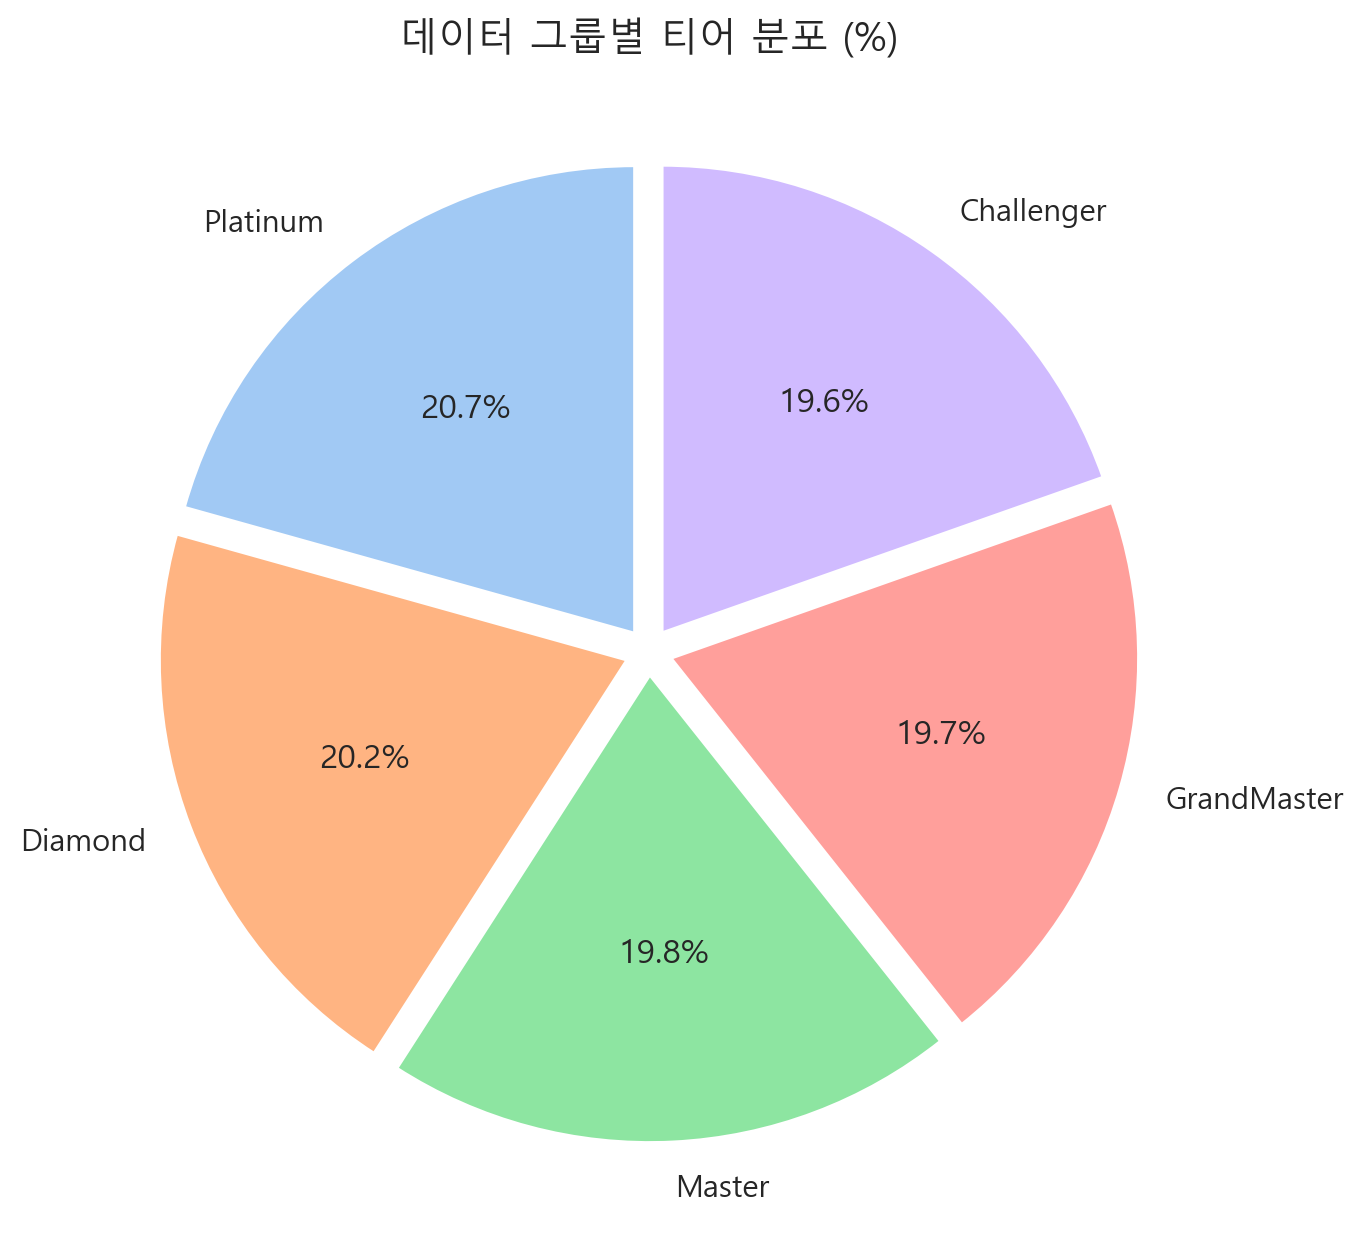

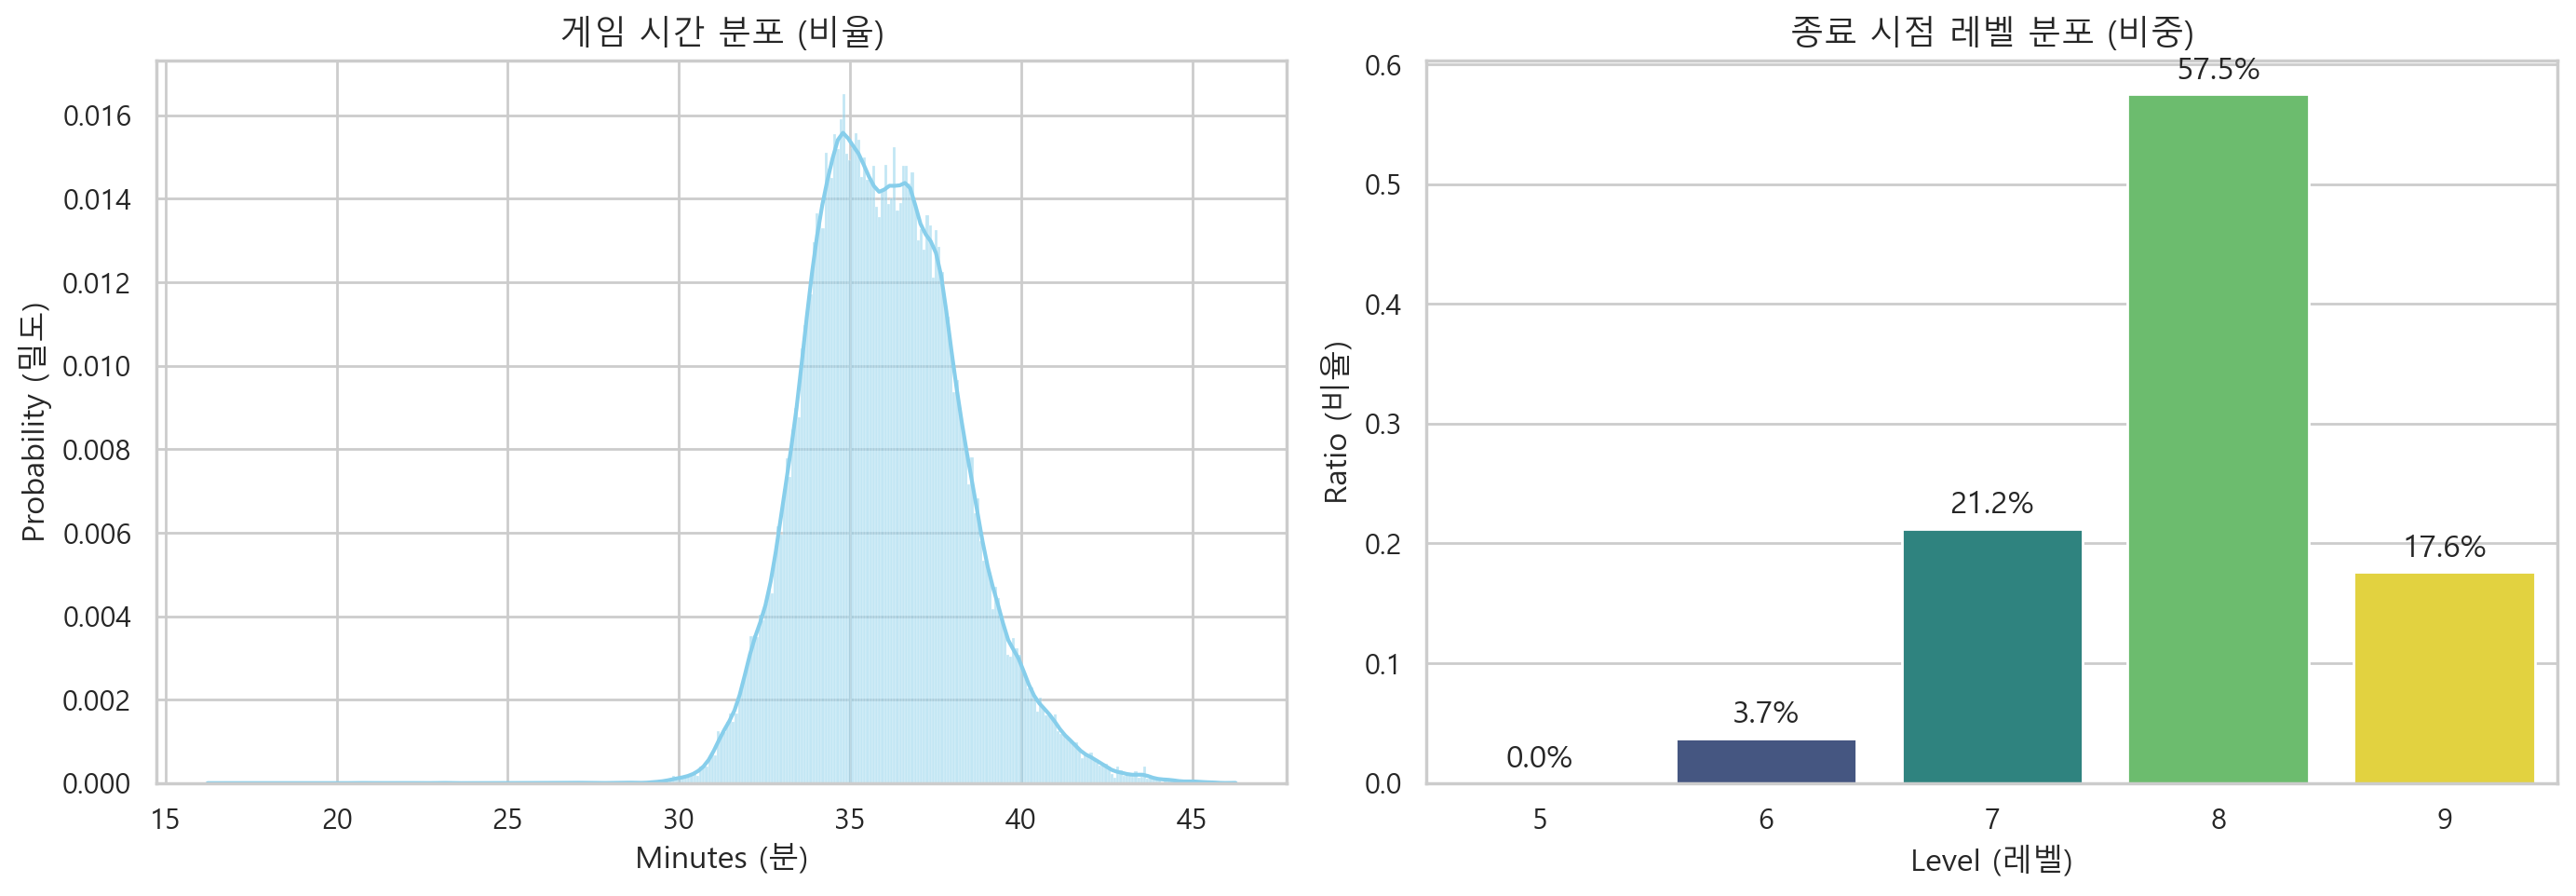

In [ ]:
# 티어/레벨 분포 집계
tier_counts = total_df['Tier'].value_counts()
tier_ratio = total_df['Tier'].value_counts(normalize=True) * 100
level_counts = total_df['level'].value_counts().sort_index()

tier_summary = pd.DataFrame({'인원수(명)': tier_counts, '비중(%)': tier_ratio})
display(tier_summary)
display(level_counts)

# 티어 비중 파이차트

plt.figure(figsize=(7, 7))
total_df['Tier'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel"),
    startangle=90,
    explode=[0.05] * len(tier_counts)
)
plt.title('데이터 그룹별 티어 분포 (%)', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

# 게임시간 맟 레벨 분포 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(total_df['gameDuration']/60, kde=True, ax=ax1, color='skyblue', stat="probability")
ax1.set_title('게임 시간 분포 (비율)', fontsize=13)
ax1.set_xlabel('Minutes (분)')
ax1.set_ylabel('Probability (밀도)')

level_ratio = total_df['level'].value_counts(normalize=True).sort_index()
sns.barplot(x=level_ratio.index, y=level_ratio.values, ax=ax2, hue=level_ratio.index, palette='viridis', legend=False)
ax2.set_title('종료 시점 레벨 분포 (비중)', fontsize=13)
ax2.set_ylabel('Ratio (비율)')
ax2.set_xlabel('Level (레벨)')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()*100:.1f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

### 전처리: 시너지 정리
활성 기준 통과 시너지 23개
필요 유닛 수를 채운 조합만 실제 선택 시너지로 반영

In [7]:
# 시너지명 한글 변환
# Riot trait key → 발표용 한글명
combination_map = {
    "Void": "공허",
    "MechPilot": "메카 파일럿",
    "Rebel": "반군",
    "Valkyrie": "발키리",
    "StarGuardian": "별 수호자",
    "Cybernetic": "사이버네틱",
    "Chrono": "시공간",
    "DarkStar": "암흑의 별",
    "SpacePirate": "우주 해적",
    "Celestial": "천상",
    "Blademaster": "검사",
    "ManaReaver": "마나 약탈자",
    "Sorcerer": "마법사",
    "Vanguard": "선봉대",
    "Protector": "수호자",
    "Mystic": "신비술사",
    "Brawler": "싸움꾼",
    "Mercenary": "용병",
    "Starship": "우주선",
    "Infiltrator": "잠입자",
    "Sniper": "저격수",
    "Blaster": "총잡이",
    "Demolitionist": "폭파광",
}

# 활성 기준
# 해당 유닛 수 이상일 때만 선택 시너지로 인정
comb_min_units = {
    "공허": 3,
    "메카 파일럿": 3,
    "반군": 3,
    "발키리": 2,
    "별 수호자": 3,
    "사이버네틱": 3,
    "시공간": 2,
    "암흑의 별": 3,
    "우주 해적": 2,
    "천상": 2,
    "검사": 3,
    "마나 약탈자": 2,
    "마법사": 2,
    "선봉대": 2,
    "수호자": 2,
    "신비술사": 2,
    "싸움꾼": 2,
    "용병": 1,
    "우주선": 1,
    "잠입자": 2,
    "저격수": 2,
    "총잡이": 2,
    "폭파광": 2,
}

# 활성 기준 이상 시너지 추출
# 조합별 최소 활성 유닛 수 충족 시 선택으로 반영
def safe_parse_comb(s):
    try:
        raw = json.loads(s.replace("'", '"'))
    except Exception:
        return {}

    out = {}
    for key, unit_cnt in raw.items():
        trait_key = key.split('_')[1] if '_' in key else key
        if trait_key not in combination_map:
            continue
        trait_name = combination_map[trait_key]
        if unit_cnt >= comb_min_units[trait_name]:
            out[trait_name] = unit_cnt
    return out

# 시너지 전처리
total_df['combination_clean'] = total_df['combination'].apply(safe_parse_comb)

# 시너지 explode
df_exploded = total_df.assign(
    synergy_list=lambda x: x['combination_clean'].apply(lambda y: list(y.items()))
).explode('synergy_list').dropna(subset=['synergy_list'])

# 시너지명·Top4 여부 생성
df_exploded['SynergyName'] = df_exploded['synergy_list'].apply(lambda x: x[0])
df_exploded['IsTop4'] = (df_exploded['Ranked'] <= 4).astype(int)

# 시너지 픽률 계산
total_games = total_df['gameId'].nunique()
pick_rates = (df_exploded['SynergyName'].value_counts() / total_games) * 100
sorted_rates = pick_rates.sort_values(ascending=False)

# 활성 시너지 수 확인
display(pd.Series({'valid_synergy_count': df_exploded['SynergyName'].nunique()}))
sorted_rates

valid_synergy_count    23
dtype: int64

SynergyName
시공간       344.554714
천상        233.223064
용병        221.388187
총잡이       206.754481
마나 약탈자    195.027868
검사        184.913188
싸움꾼       177.533181
마법사       140.693292
선봉대       131.577048
저격수       123.617627
발키리       123.244717
잠입자       107.548418
신비술사      105.349052
수호자        91.866153
암흑의 별      80.887365
반군         80.805165
사이버네틱      75.554353
폭파광        73.106380
메카 파일럿     72.697382
우주 해적      64.579574
별 수호자      58.105778
우주선        40.755443
공허         30.510445
Name: count, dtype: float64

### 메타 쏠림
상위 시너지 누적 점유율 확인
시공간·천상·용병·총잡이 중심 반복 선택 구조

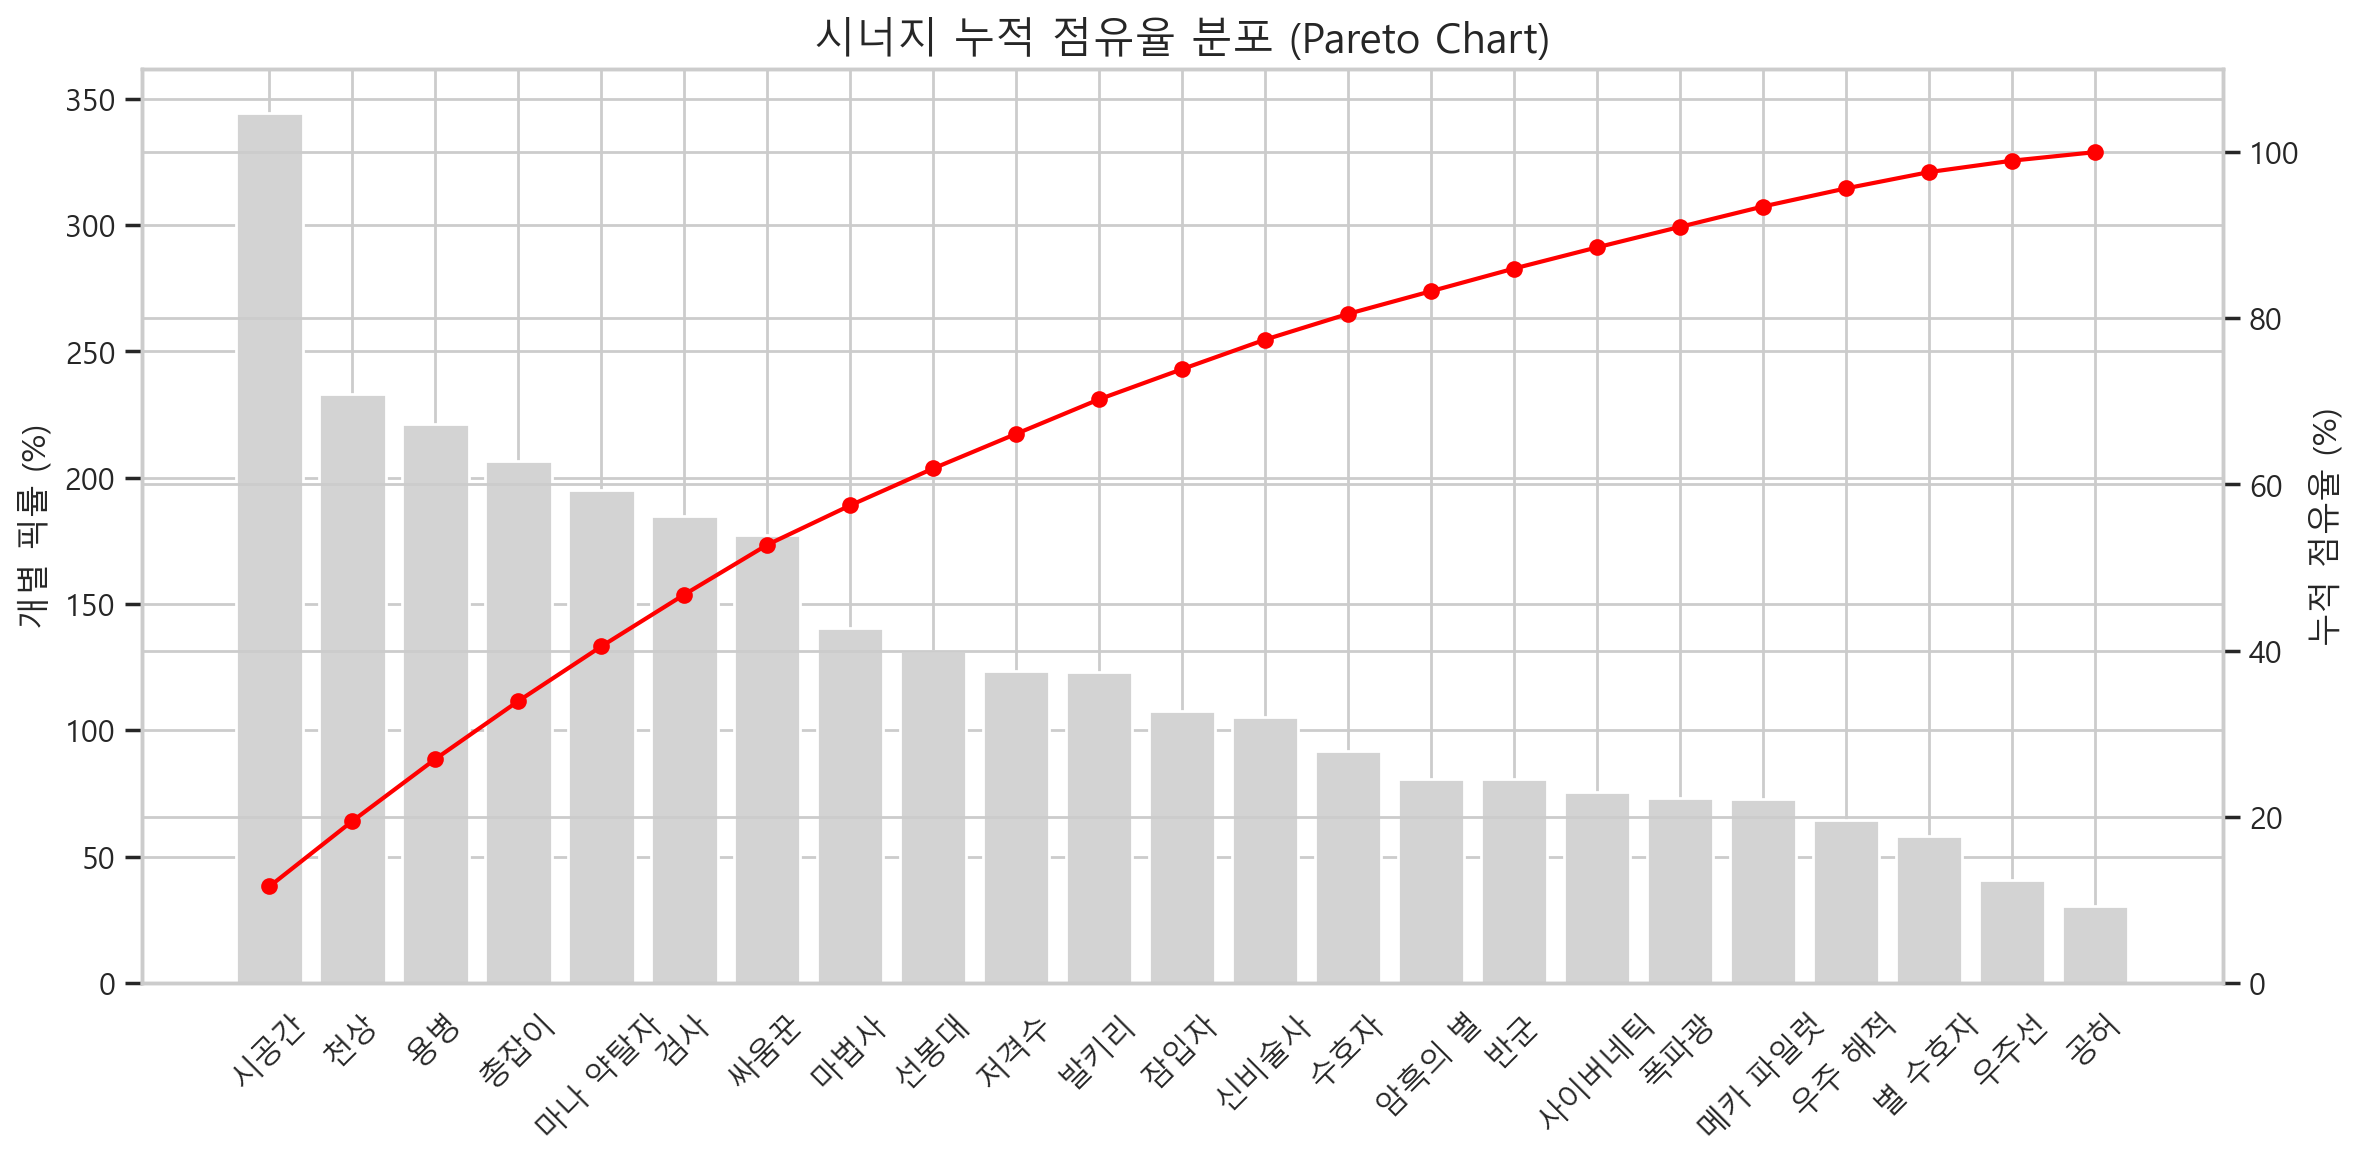

In [8]:
# 누적 점유율 계산
cumulative = sorted_rates.cumsum() / sorted_rates.sum() * 100

# Pareto Chart 생성
fig, ax1 = plt.subplots(figsize=(12, 6))

# 개별 픽률 막대
ax1.bar(sorted_rates.index, sorted_rates.values, color='lightgrey')
ax1.set_ylabel('개별 픽률 (%)')
ax1.tick_params(axis='x', rotation=45)

# 누적 점유율 선 그래프
ax2 = ax1.twinx()
ax2.plot(sorted_rates.index, cumulative.values, color='red', marker='o', ms=5)
ax2.set_ylabel('누적 점유율 (%)')
ax2.set_ylim(0, 110)

# 차트 출력
plt.title('시너지 누적 점유율 분포 (Pareto Chart)', fontsize=15)
plt.tight_layout()
plt.show()

### 활성 시너지 수 기술통계
유저당 평균 활성 시너지 8.57개, 중앙값 8개
한 판에서 여러 조합이 동시에 켜져 선택 쏠림 해석 시 중복 활성 고려 필요

In [9]:
# 유저별 활성 시너지 수
# 원본 combination에 기록된 조합 개수 기준
active_synergies_per_game = total_df['combination'].apply(lambda x: len(ast.literal_eval(x)))

avg_synergies = active_synergies_per_game.mean()
active_synergies_per_game.describe()

count    328532.000000
mean          8.566758
std           1.396729
min           0.000000
25%           8.000000
50%           8.000000
75%           9.000000
max          17.000000
Name: combination, dtype: float64

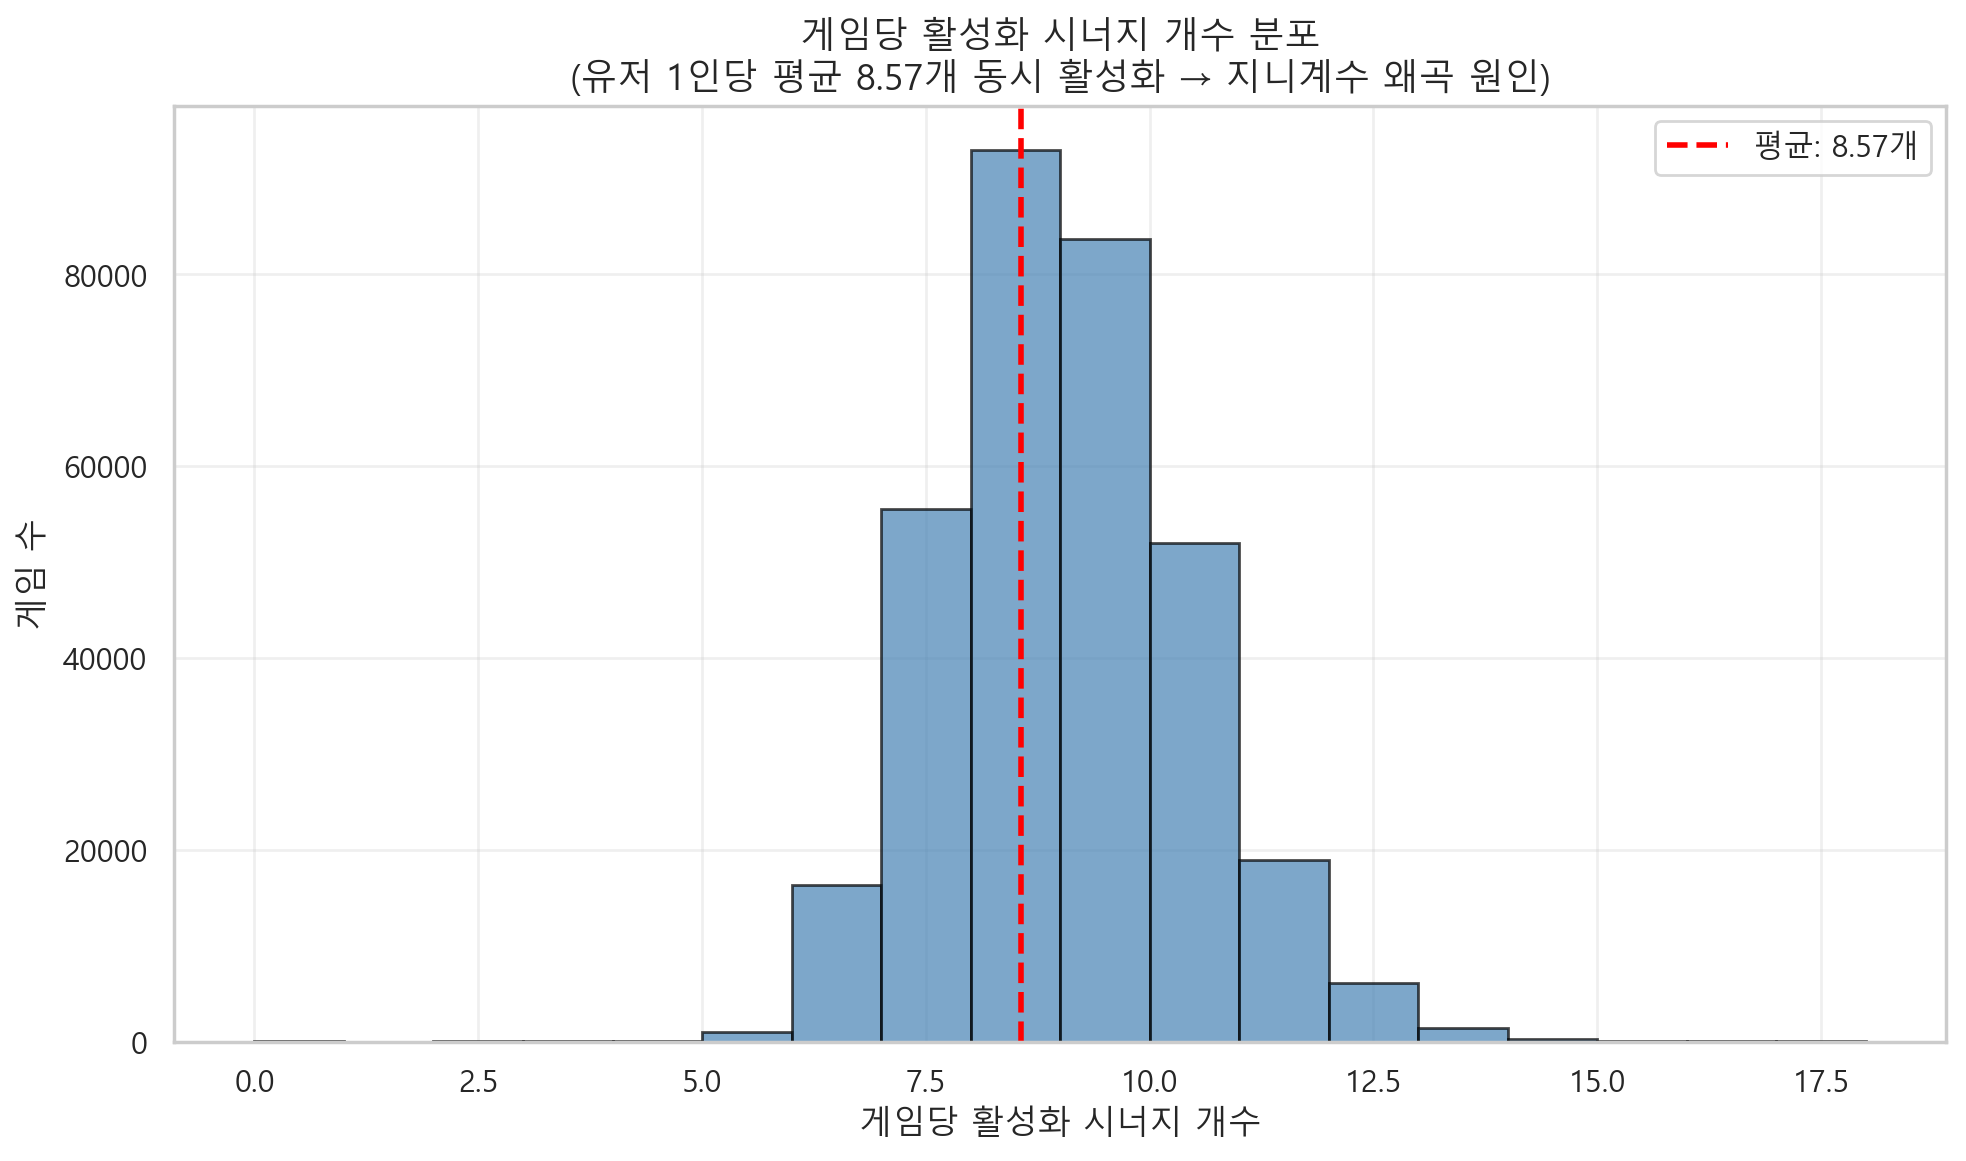

In [10]:
# 게임당 활성 시너지 수 분포
plt.figure(figsize=(10, 6))

# 활성 시너지 히스토그램
plt.hist(active_synergies_per_game,
         bins=range(active_synergies_per_game.min(), active_synergies_per_game.max() + 2),
         color='steelblue', edgecolor='black', alpha=0.7)

# 평균 활성 시너지 수
plt.axvline(avg_synergies, color='red', linestyle='--', linewidth=2, label=f'평균: {avg_synergies:.2f}개')

# 차트 설정
plt.xlabel('게임당 활성화 시너지 개수')
plt.ylabel('게임 수')
plt.title(f'게임당 활성화 시너지 개수 분포\n(유저 1인당 평균 {avg_synergies:.2f}개 동시 활성화 → 지니계수 왜곡 원인)', fontsize=13)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


plt.show()

### 집중도
Gini 0.3079, 티어별 HHI 기준 메타 집중도 확인
완전 독점은 아니지만 상위 조합 반복 선택 구조

0.3079


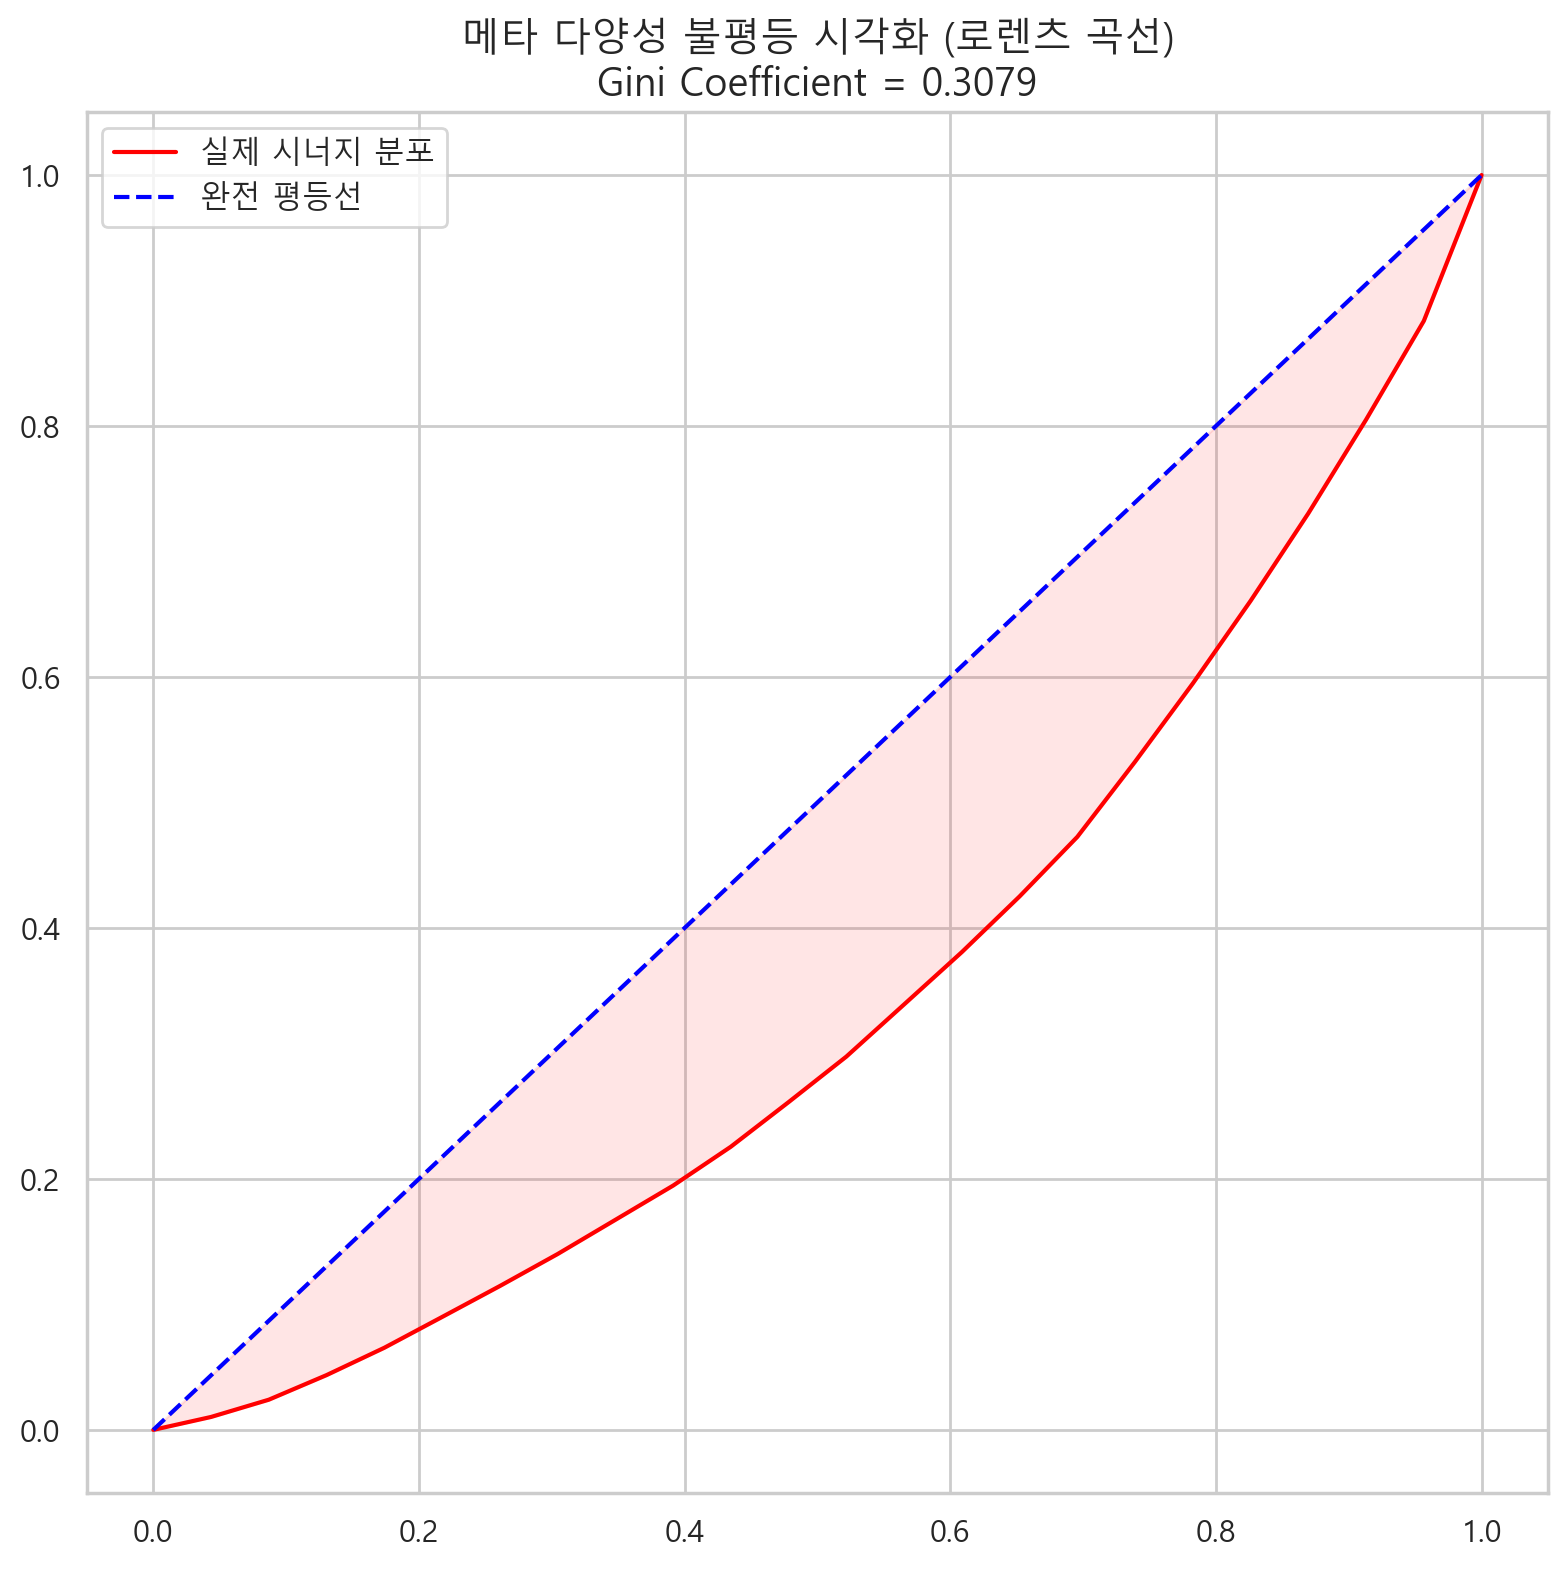

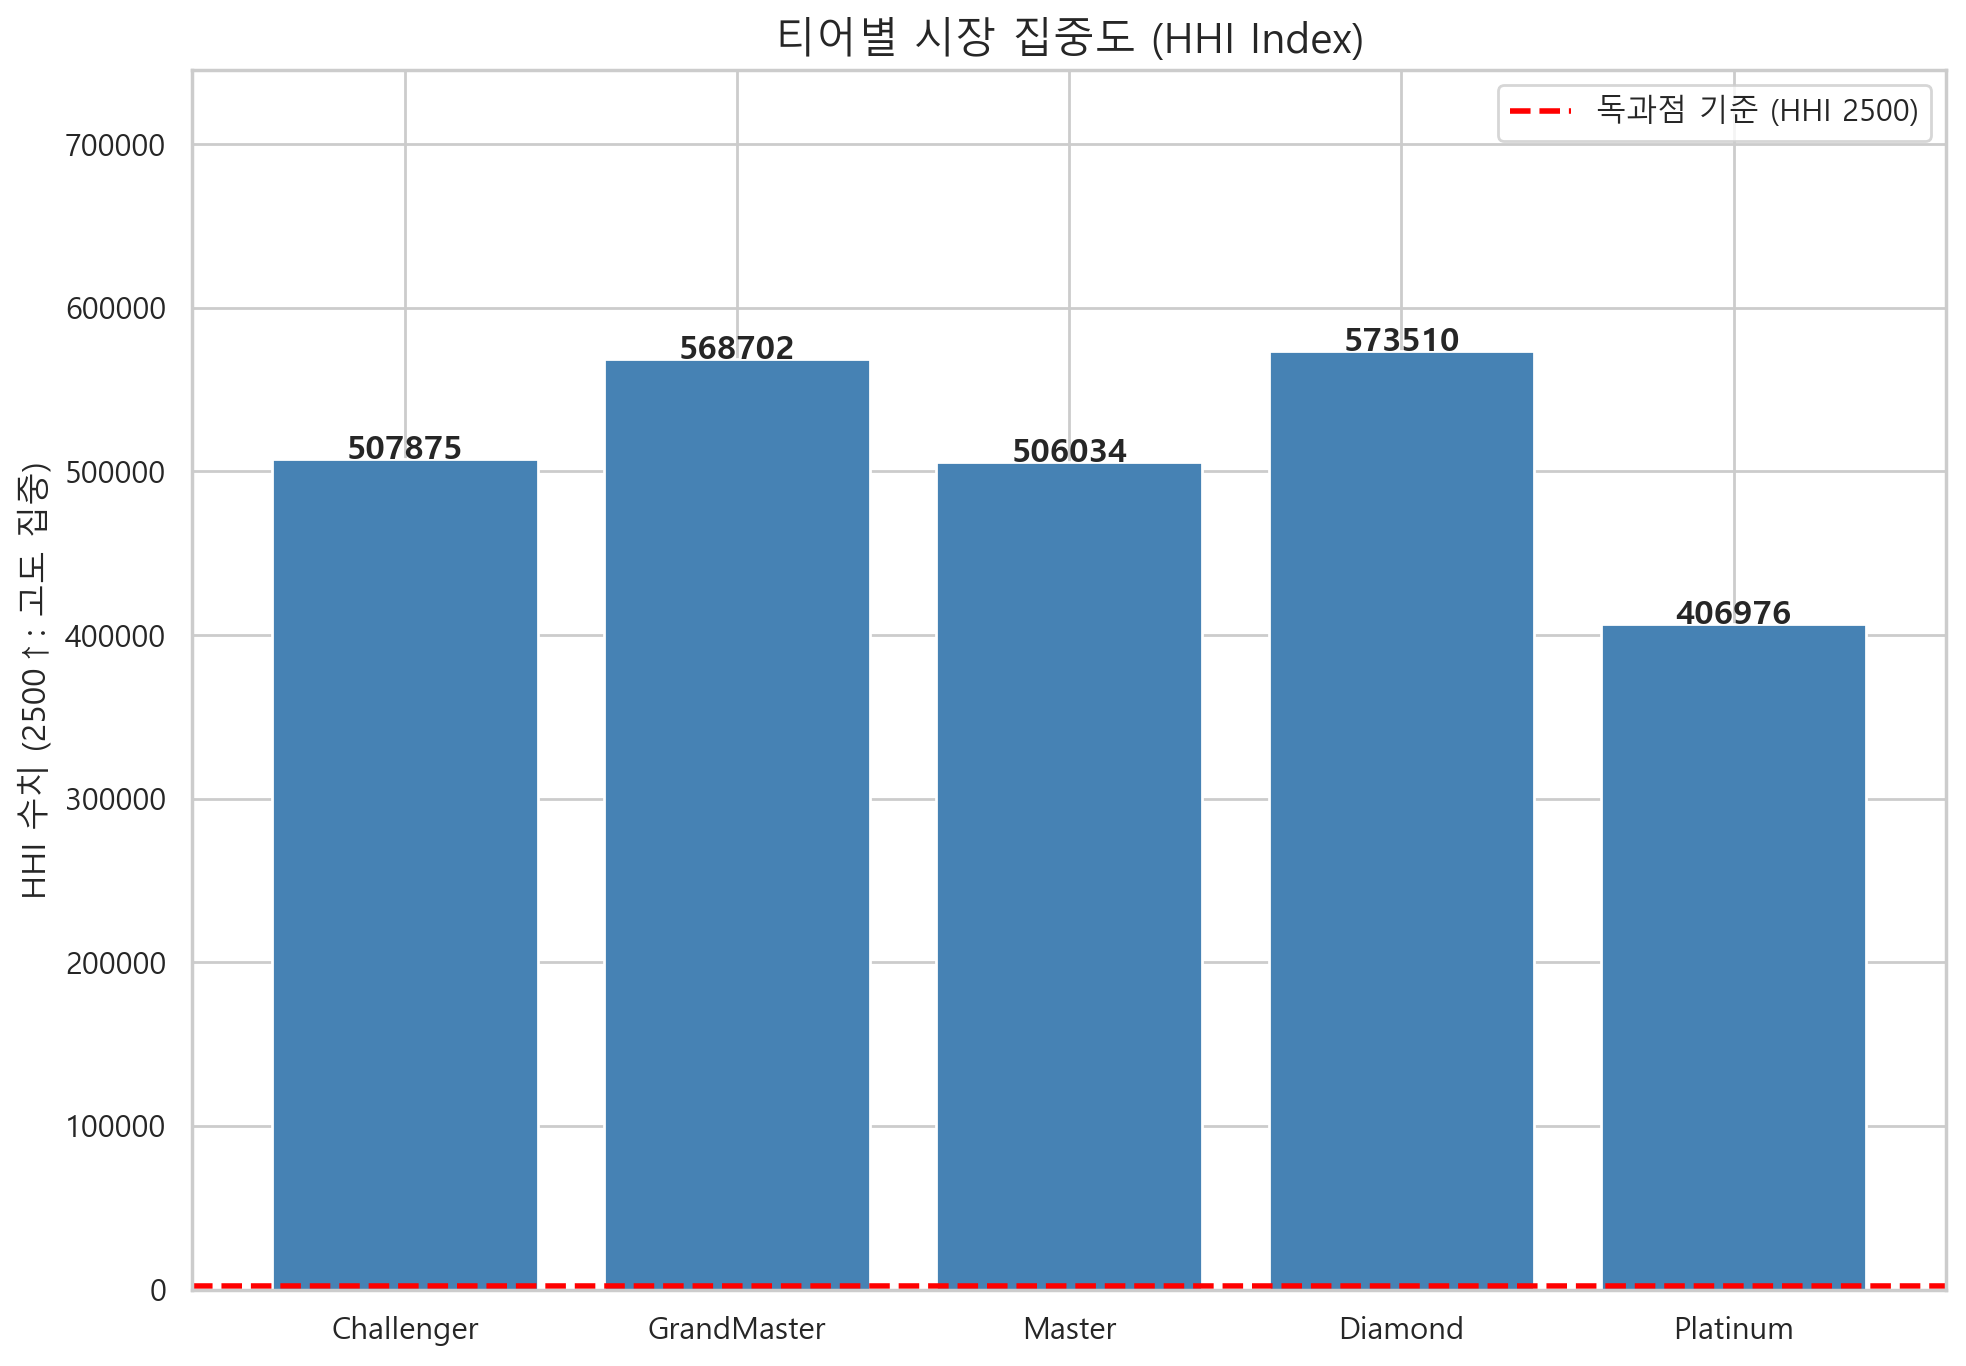

In [11]:
# 로렌츠 곡선
lorenz = np.cumsum(np.sort(sorted_rates.values)) / sorted_rates.sum()
lorenz = np.insert(lorenz, 0, 0)
equality = np.linspace(0, 1, len(lorenz))

# 지니계수
gini_coefficient = 1 - 2 * np.sum((lorenz[:-1] + lorenz[1:]) / 2 * np.diff(equality))
print(round(gini_coefficient, 4))

# 차트 설정
plt.figure(figsize=(8, 8))
plt.plot(equality, lorenz, color='red', label='실제 시너지 분포')
plt.plot(equality, equality, color='blue', linestyle='--', label='완전 평등선')
plt.fill_between(equality, equality, lorenz, color='red', alpha=0.1)
plt.title(f'메타 다양성 불평등 시각화 (로렌츠 곡선)\nGini Coefficient = {gini_coefficient:.4f}', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# 티어별 HHI
# 티어 순서 고정
tiers = ['Challenger', 'GrandMaster', 'Master', 'Diamond', 'Platinum']
hhi_results = []
for tier in tiers:
    t_data = df_exploded[df_exploded['Tier'] == tier]['SynergyName'].value_counts()
    t_rates = (t_data / total_df[total_df['Tier'] == tier]['gameId'].nunique()) * 100
    hhi_val = (t_rates**2 / 100**2).sum() * 10000
    hhi_results.append(hhi_val)

# 차트 설정
plt.figure(figsize=(10, 7))
bars = plt.bar(tiers, hhi_results, color='steelblue')
plt.axhline(2500, color='red', linestyle='--', linewidth=2, label='독과점 기준 (HHI 2500)')
plt.ylim(0, max(hhi_results) * 1.3)
plt.title('티어별 시장 집중도 (HHI Index)', fontsize=15)
plt.ylabel('HHI 수치 (2500↑: 고도 집중)')
plt.legend()

# 막대 상단 값 표시
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{bar.get_height():.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 검정: 시너지 성과 차이
- 카이제곱: 시너지 선택과 Top4 진입 관계
- Kruskal-Wallis: 시너지별 순위 분포 차이
- ANOVA: 시너지별 평균 순위 차이
- p-value 0.05 미만 기준 유의, effect는 효과 크기


In [12]:
# 검정용 인덱스 정리
df_exploded = df_exploded.reset_index(drop=True)

# 카이제곱
# 시너지 선택 분포와 Top4 진입 관계
top4_synergy = pd.crosstab(df_exploded['SynergyName'], df_exploded['IsTop4'])
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(top4_synergy)
n = top4_synergy.values.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(top4_synergy.shape) - 1)))

# Kruskal-Wallis
# 정규성 가정 없이 시너지별 순위 분포 차이 확인
rank_groups = [
    df_exploded.loc[df_exploded['SynergyName'] == s, 'Ranked'].values
    for s in df_exploded['SynergyName'].unique()
]
H_stat, p_kruskal = stats.kruskal(*rank_groups)

# ANOVA
# 시너지별 평균 순위 차이 확인
F_stat, p_anova = stats.f_oneway(*rank_groups)

# 효과크기
ss_between = sum(
    len(g) * (np.mean(g) - df_exploded['Ranked'].mean())**2
    for g in rank_groups
)
ss_total = ((df_exploded['Ranked'] - df_exploded['Ranked'].mean())**2).sum()
eta_squared = ss_between / ss_total

# 통계 검정 결과 요약
stat_check = pd.DataFrame([
    ['chi_square', chi2_stat, p_chi2, cramers_v, 'Cramer_V', '유의'],
    ['kruskal_wallis', H_stat, p_kruskal, np.nan, '비모수 검정, effect 미산출', '유의'],
    ['anova', F_stat, p_anova, eta_squared, 'eta_squared', '유의'],
], columns=['test', 'stat', 'p_value', 'effect', 'effect_note', 'result'])

stat_check

,test,stat,p_value,effect,effect_note,result
0,chi_square,7775.781984,0.0,0.072520,Cramer_V,유의
1,kruskal_wallis,9782.695846,0.0,NaN,"비모수 검정, effect 미산출",유의
2,anova,453.499398,0.0,0.006703,eta_squared,유의


### 구조 확인
티어별 시너지 선택 비중 확인
모든 티어에서 반복되는 핵심 시너지 존재

In [13]:
# 티어별 시너지 비중
# 상위 티어에서도 같은 조합만 반복되는지 확인

# 티어 정보 병합
if 'Tier' not in df_exploded.columns:
    tier_map = total_df.drop_duplicates('gameId')[['gameId','Tier']]
    df_exploded = df_exploded.merge(tier_map, on='gameId', how='left')

# 티어 순서·색상 설정
tier_order = ['Challenger', 'GrandMaster', 'Master', 'Diamond', 'Platinum']
tier_color_map = {
    'Challenger':  '#FF6B6B',
    'GrandMaster': '#FF9F40',
    'Master':      '#FFCE56',
    'Diamond':     '#4BC0C0',
    'Platinum':    '#36A2EB',}

# 티어별 시너지 선택 비중 계산
tier_synergy = (
    df_exploded.groupby(['Tier', 'SynergyName'])
    .size()
    .reset_index(name='count'))

tier_total = df_exploded.groupby('Tier').size().rename('total')
tier_synergy = tier_synergy.join(tier_total, on='Tier')
tier_synergy['pct'] = tier_synergy['count'] / tier_synergy['total'] * 100
tier_pivot = tier_synergy.pivot(index='Tier', columns='SynergyName', values='pct').fillna(0)


# 시너지 평균 비중 기준 정렬
synergy_order = tier_pivot.mean(axis=0).sort_values(ascending=False).index.tolist()

# 티어별 선택 비중 버블 차트
fig = go.Figure()

for tier in tier_order:
    if tier not in tier_pivot.index:
        continue
    y_vals = tier_pivot.loc[tier, synergy_order].values

    fig.add_trace(go.Scatter(
        x=synergy_order,
        y=y_vals,
        mode='markers',
        name=tier,
        marker=dict(
            color=tier_color_map[tier],
            # 비중 기반 버블 크기
            size=[(v * 1.5) + 12 for v in y_vals], 
            opacity=0.6,
            line=dict(width=1.2, color='white')
        )
    ))

# 레이아웃
fig.update_layout(
    title=dict(
        text='<b>티어별 시너지 선택 비중 분석</b>',
        font=dict(size=20, color='#2c3e50'),
        x=0.05, 
        y=0.95
    ),
    template='plotly_white',
    height=600,
    margin=dict(t=100, b=120, l=80, r=50),
    
# 범례
    legend=dict(
        title='<b>티어</b>',
        yanchor='top',
        y=0.95,      
        xanchor='right', 
        x=0.98,          
        bgcolor='rgba(255, 255, 255, 0.9)', 
        bordercolor='black',                 
        borderwidth=1                        
    ),

    # 축 설정
    yaxis=dict(
        title='선택 비중 (%)',
        gridcolor='rgba(200, 200, 200, 0.2)',
        zeroline=False,
        range=[0, max(tier_pivot.max()) * 1.2] # 상단 여백
    ),
    xaxis=dict(
        title='시너지 이름',
        tickangle=-45,
        gridcolor='rgba(200, 200, 200, 0.2)'
    )
)

fig.show()

C:\Users\ckcma\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




### 동시 선택 : 시너지 조합 상관관계 히트맵
시너지 동시 등장 패턴 확인
강한 조합 묶음 보상 후보 탐색

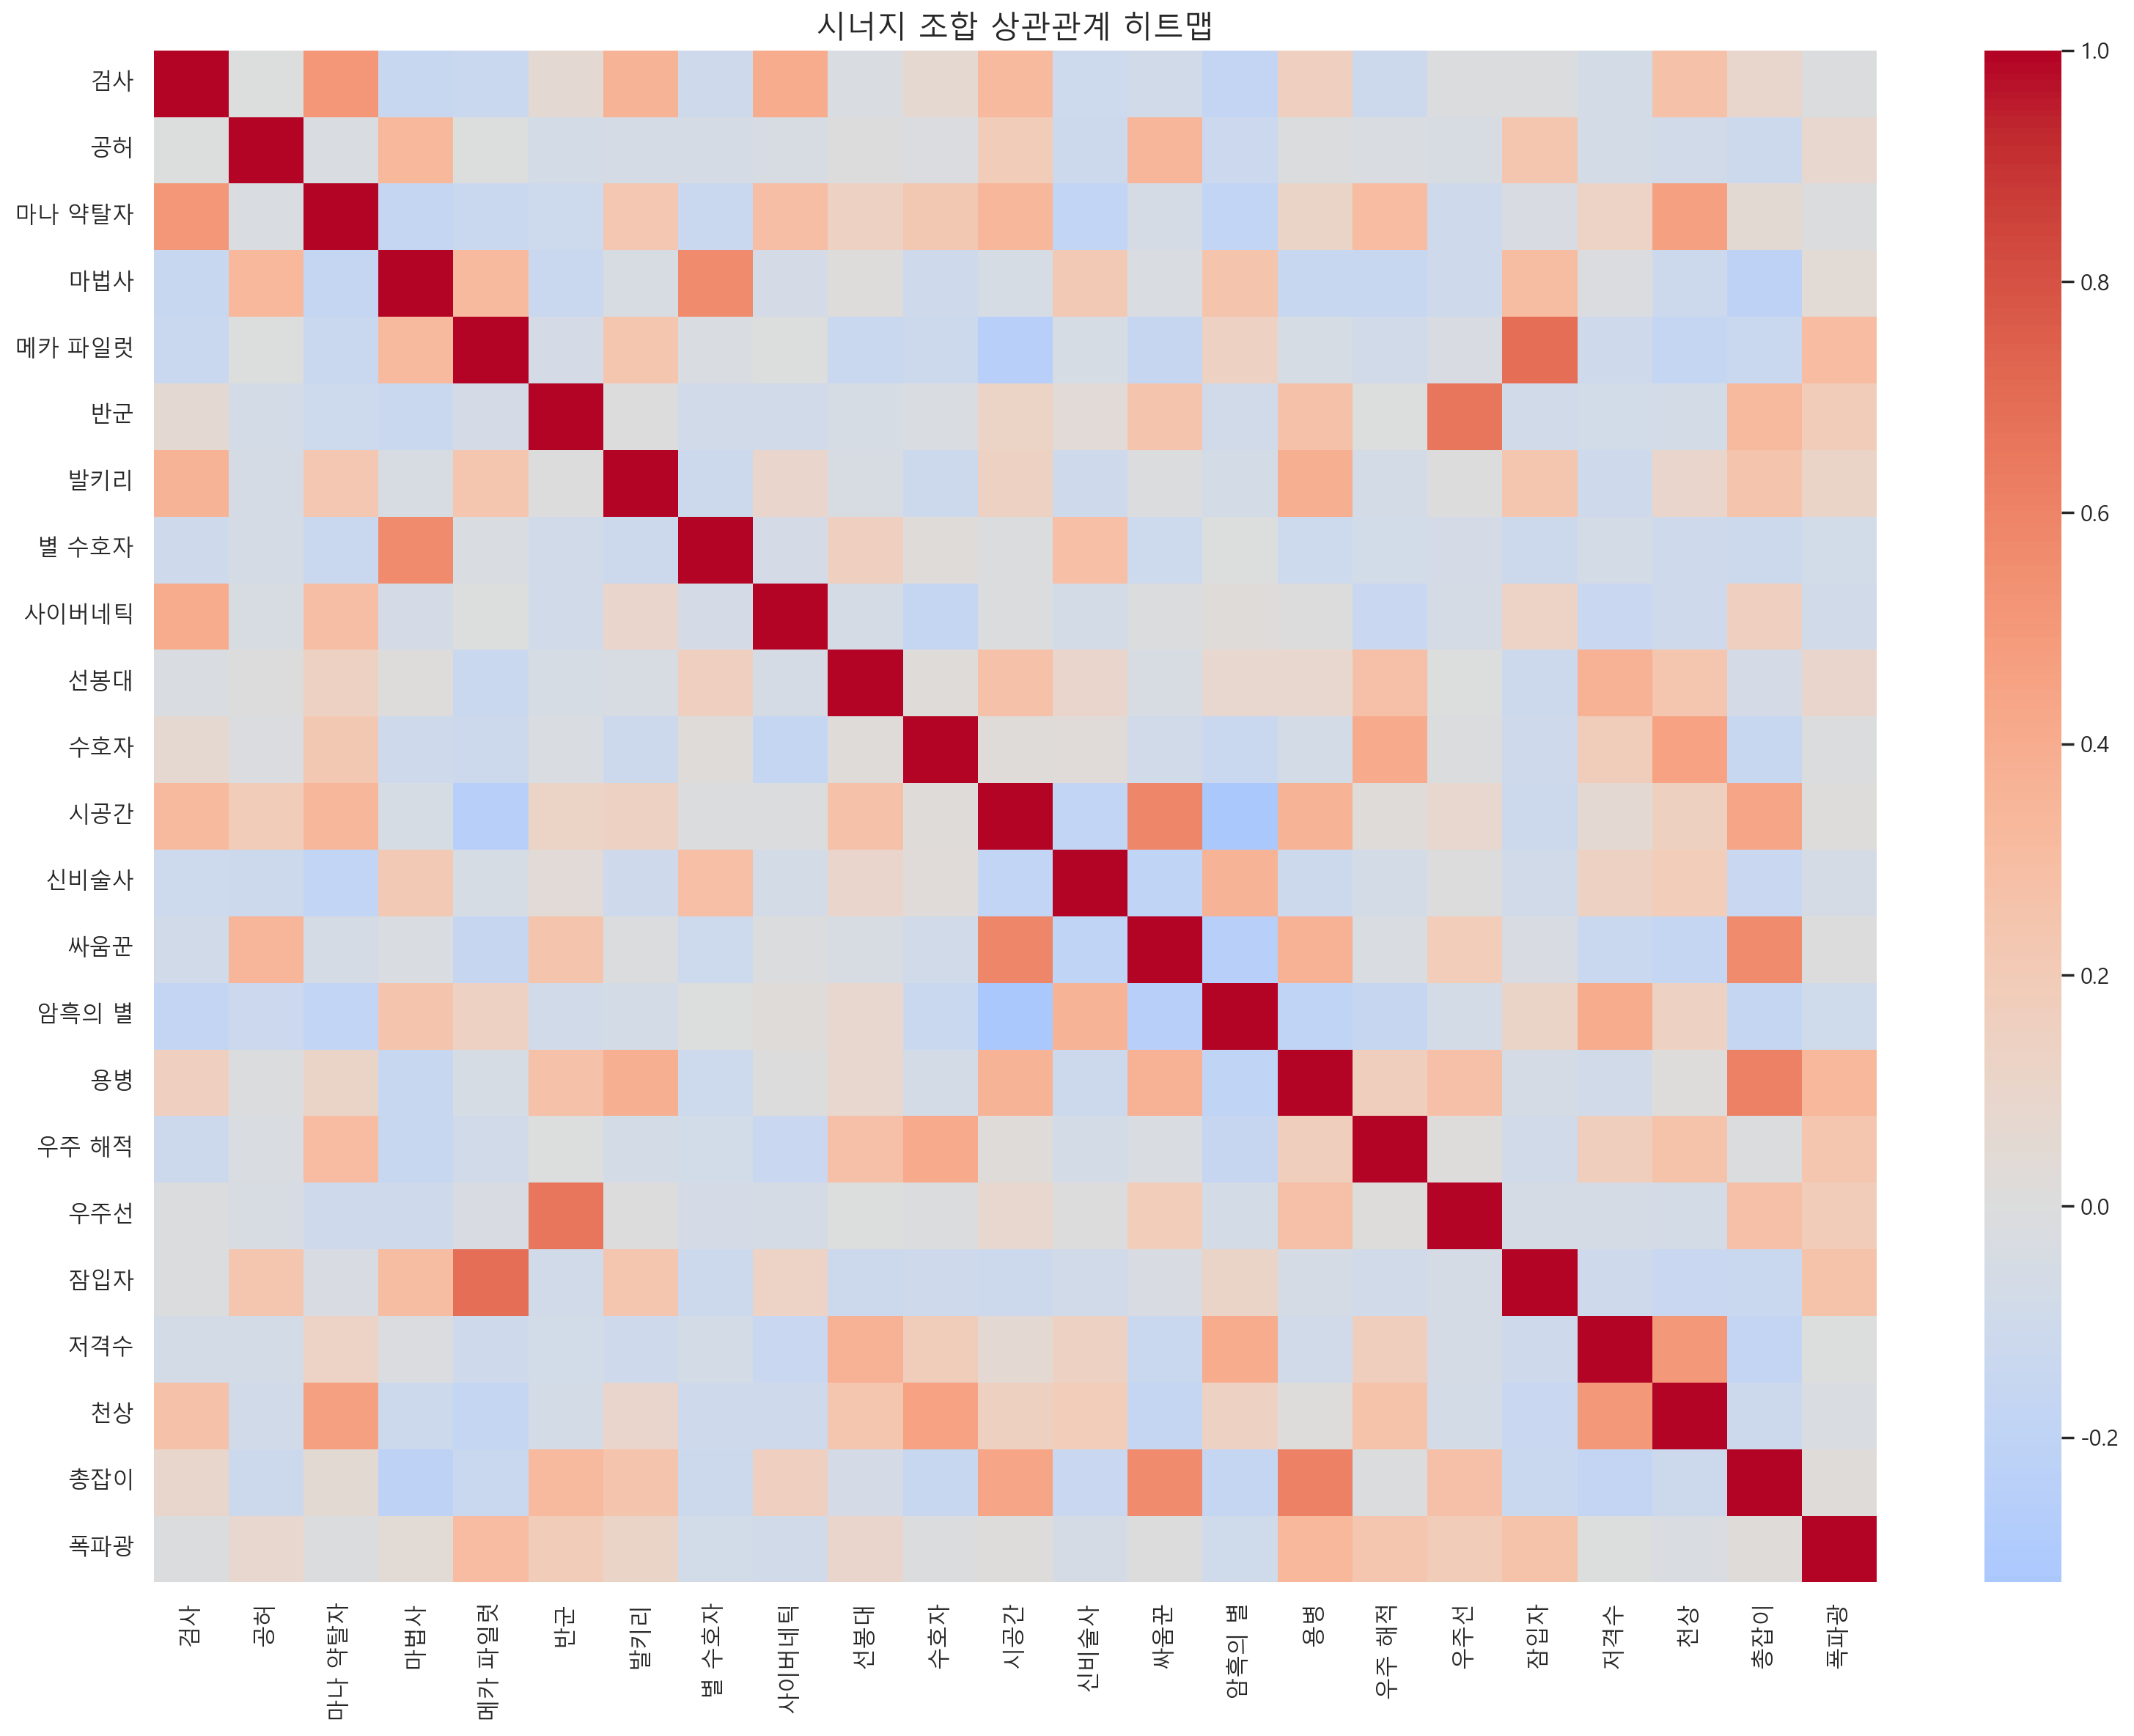

In [14]:
# 게임-시너지 매트릭스 생성
synergy_matrix = pd.get_dummies(df_exploded['SynergyName']).groupby(df_exploded['gameId']).sum()

# 시너지 조합 상관계수 히트맵
plt.figure(figsize=(16, 12))

sns.heatmap(synergy_matrix.corr(), cmap='coolwarm', center=0)

# 차트 출력
plt.title('시너지 조합 상관관계 히트맵', fontsize=15)
plt.tight_layout()
plt.show()

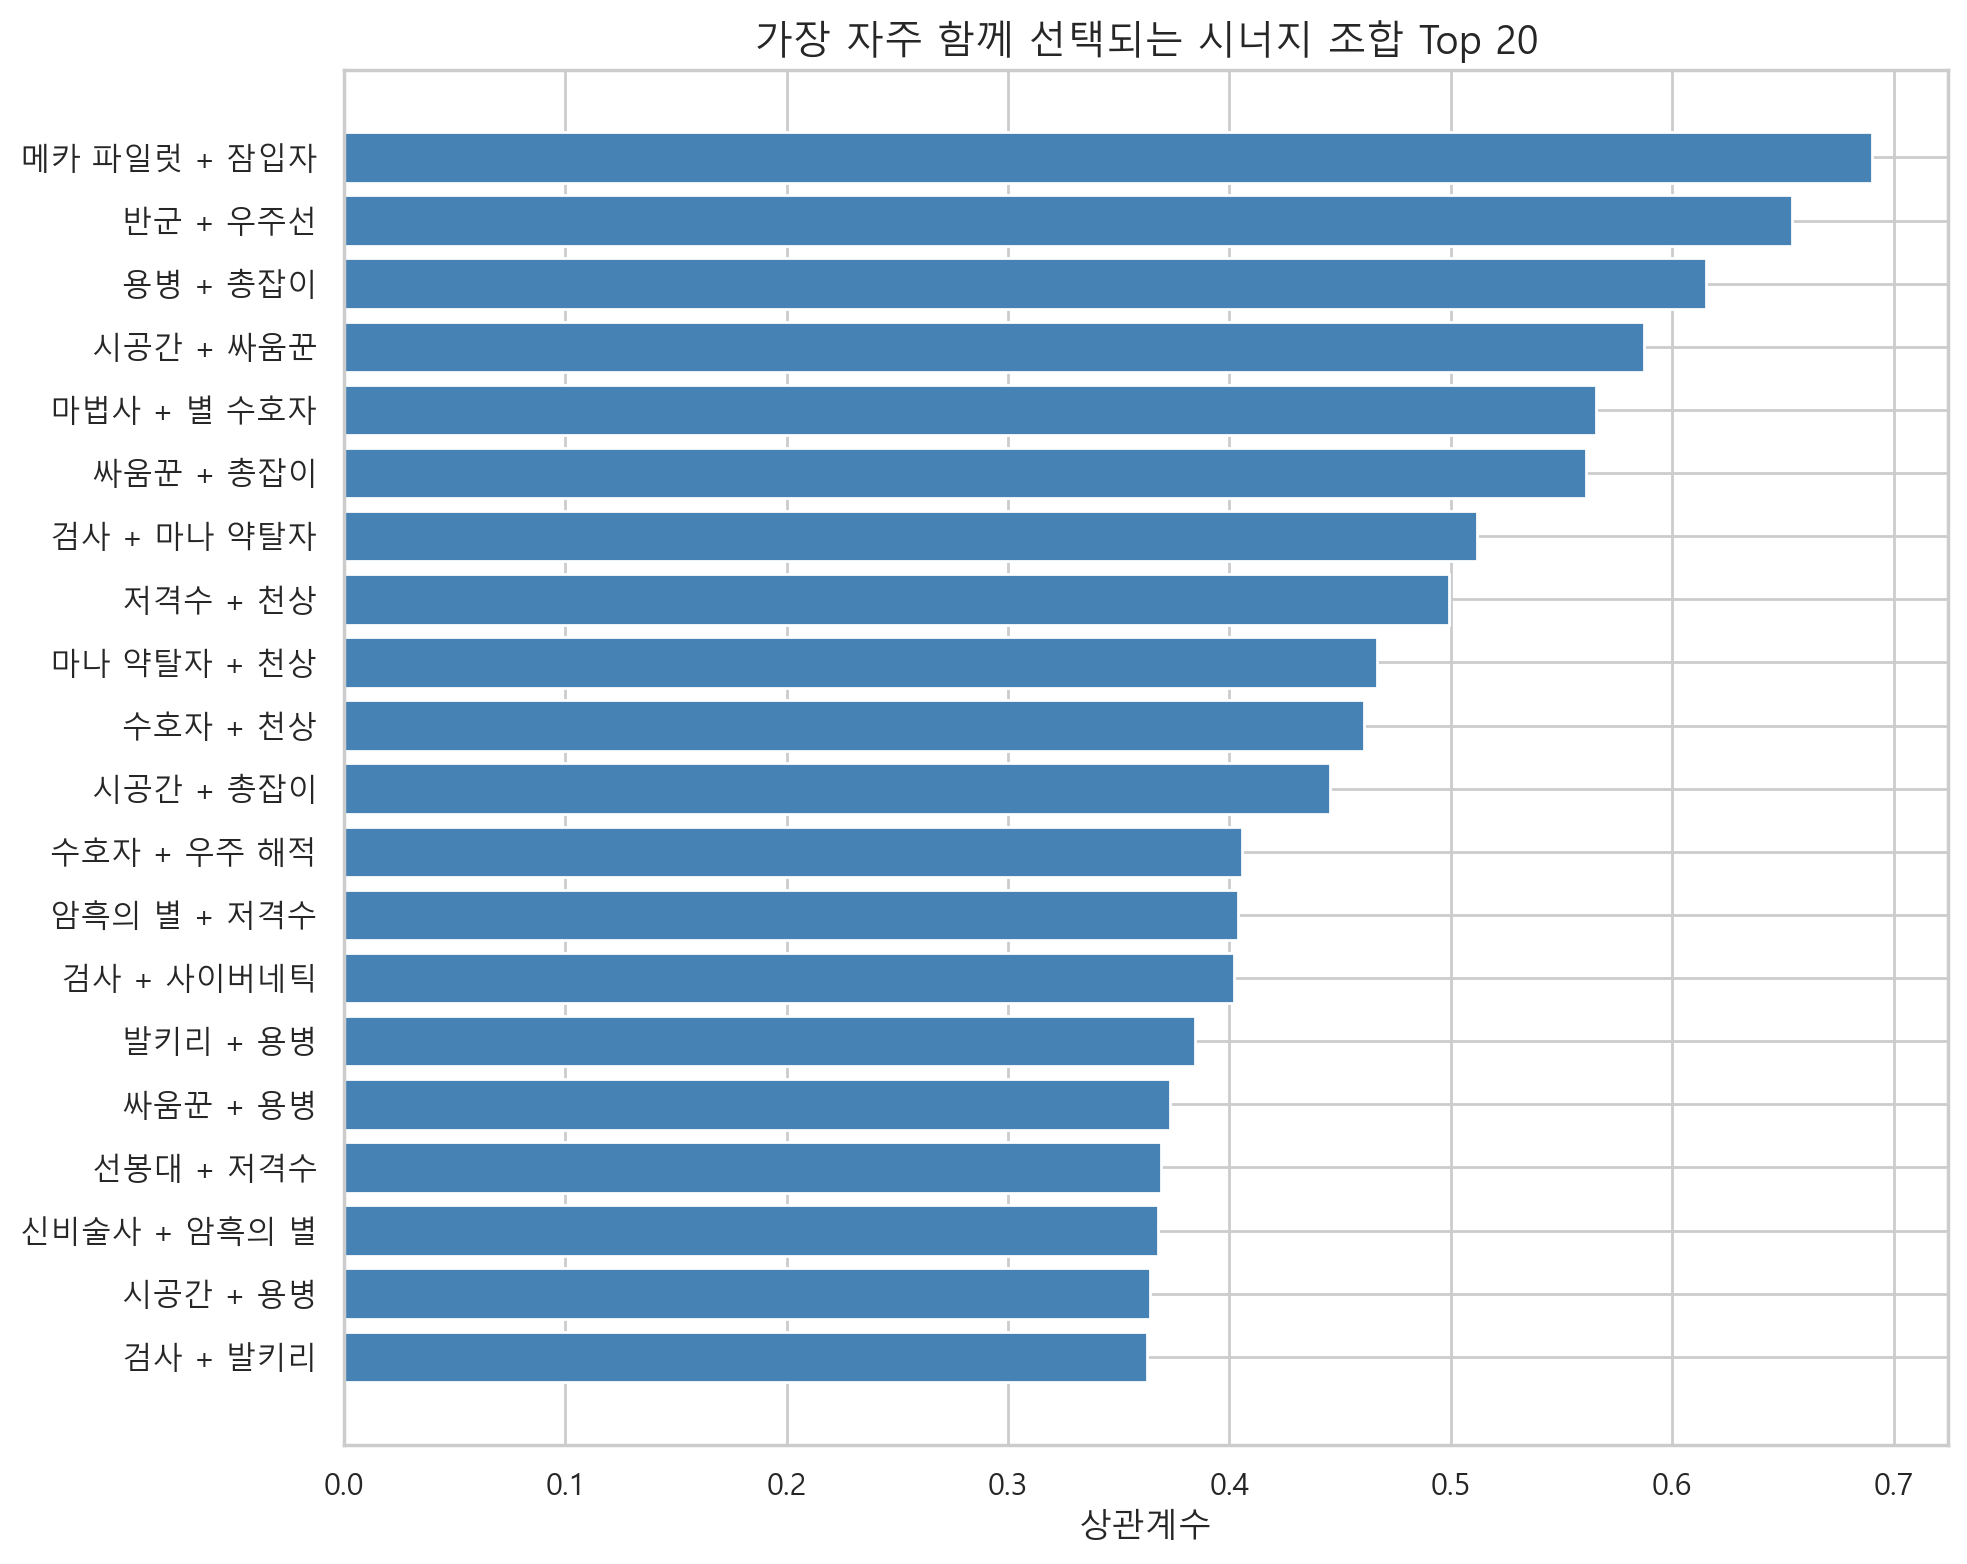

In [15]:
# 게임-시너지 상위 매트릭스 생성
synergy_matrix = pd.get_dummies(df_exploded['SynergyName']).groupby(df_exploded['gameId']).sum()

# 시너지 상관계수 계산
corr = synergy_matrix.corr()

# 중복·대각선 제거 후 상위 조합 추출
corr_unstacked = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pairs = corr_unstacked.sort_values(ascending=False).head(20)

# 조합 라벨 생성
labels = [f"{a} + {b}" for a, b in top_pairs.index]
plt.figure(figsize=(10, 8))
plt.barh(labels[::-1], top_pairs.values[::-1], color='steelblue')

# 기준선
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# 차트 출력
plt.xlabel('상관계수')
plt.title('가장 자주 함께 선택되는 시너지 조합 Top 20', fontsize=14)
plt.tight_layout()
plt.show()

### 레벨과 순위
상위권 진입 구간의 종료 레벨 분포 확인
고레벨 전략 보상 기준 참고

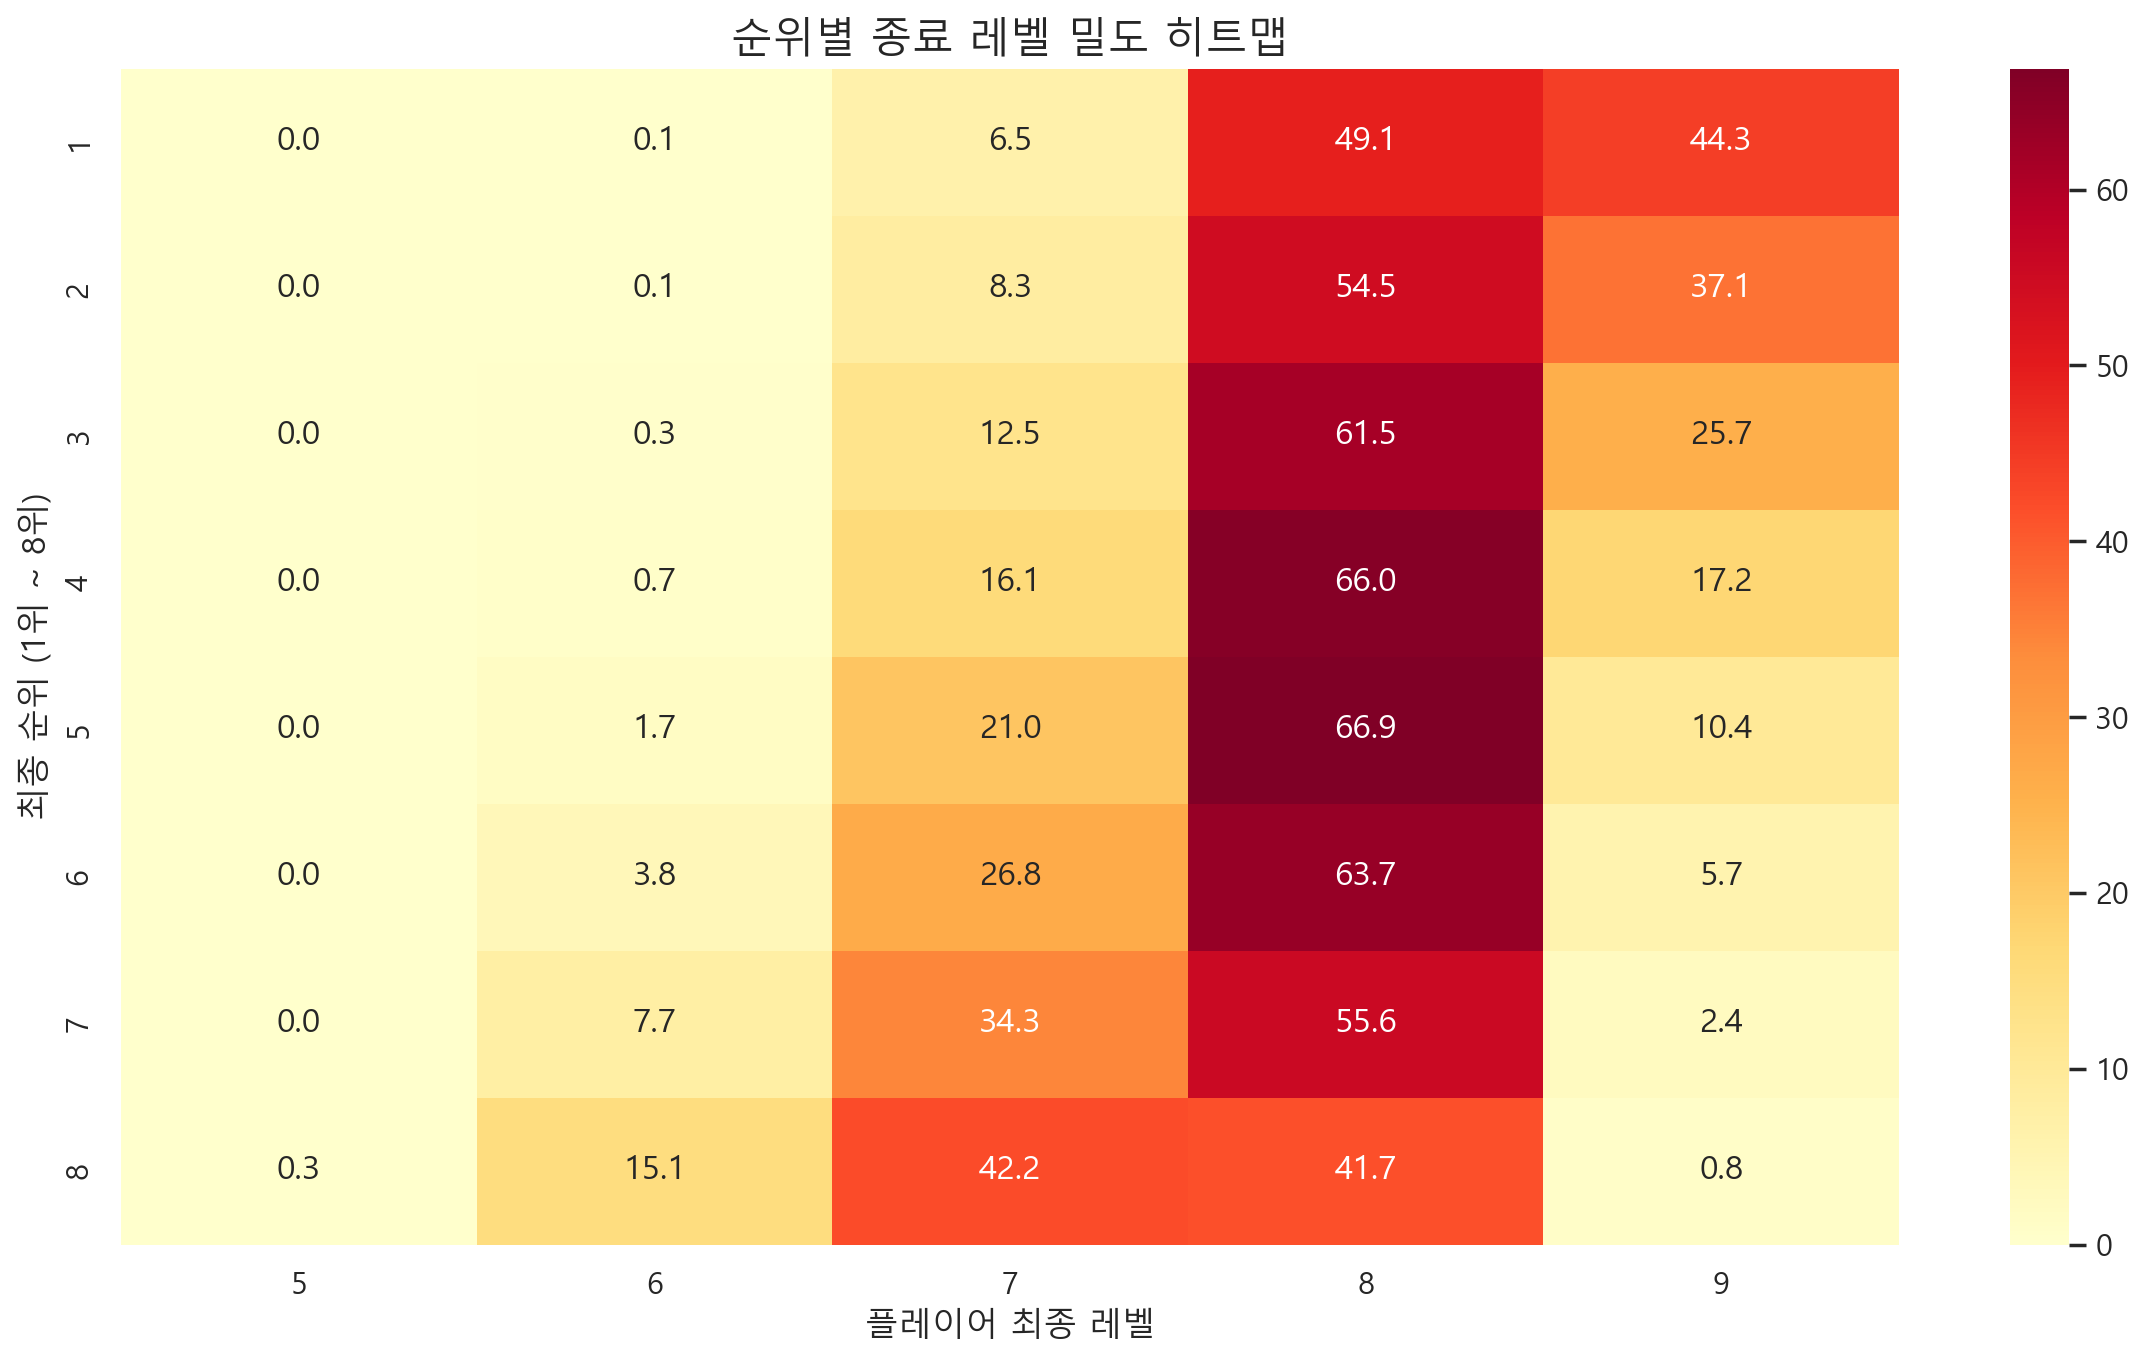

In [16]:
# 순위-레벨 분포 테이블
risk_pivot = total_df.groupby(['Ranked', 'level']).size().unstack(fill_value=0)

# 순위 기준 비율 정규화
risk_pivot_norm = risk_pivot.div(risk_pivot.sum(axis=1), axis=0) * 100

# 순위별 종료 레벨 히트맵
plt.figure(figsize=(12, 7))
sns.heatmap(risk_pivot_norm, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('순위별 종료 레벨 밀도 히트맵', fontsize=15)
plt.xlabel('플레이어 최종 레벨')
plt.ylabel('최종 순위 (1위 ~ 8위)')
plt.tight_layout()
plt.show()

### Top4 시너지 (승리 조합)
Top4 진입 시 자주 등장한 시너지 확인
사분면 성과 축 입력값

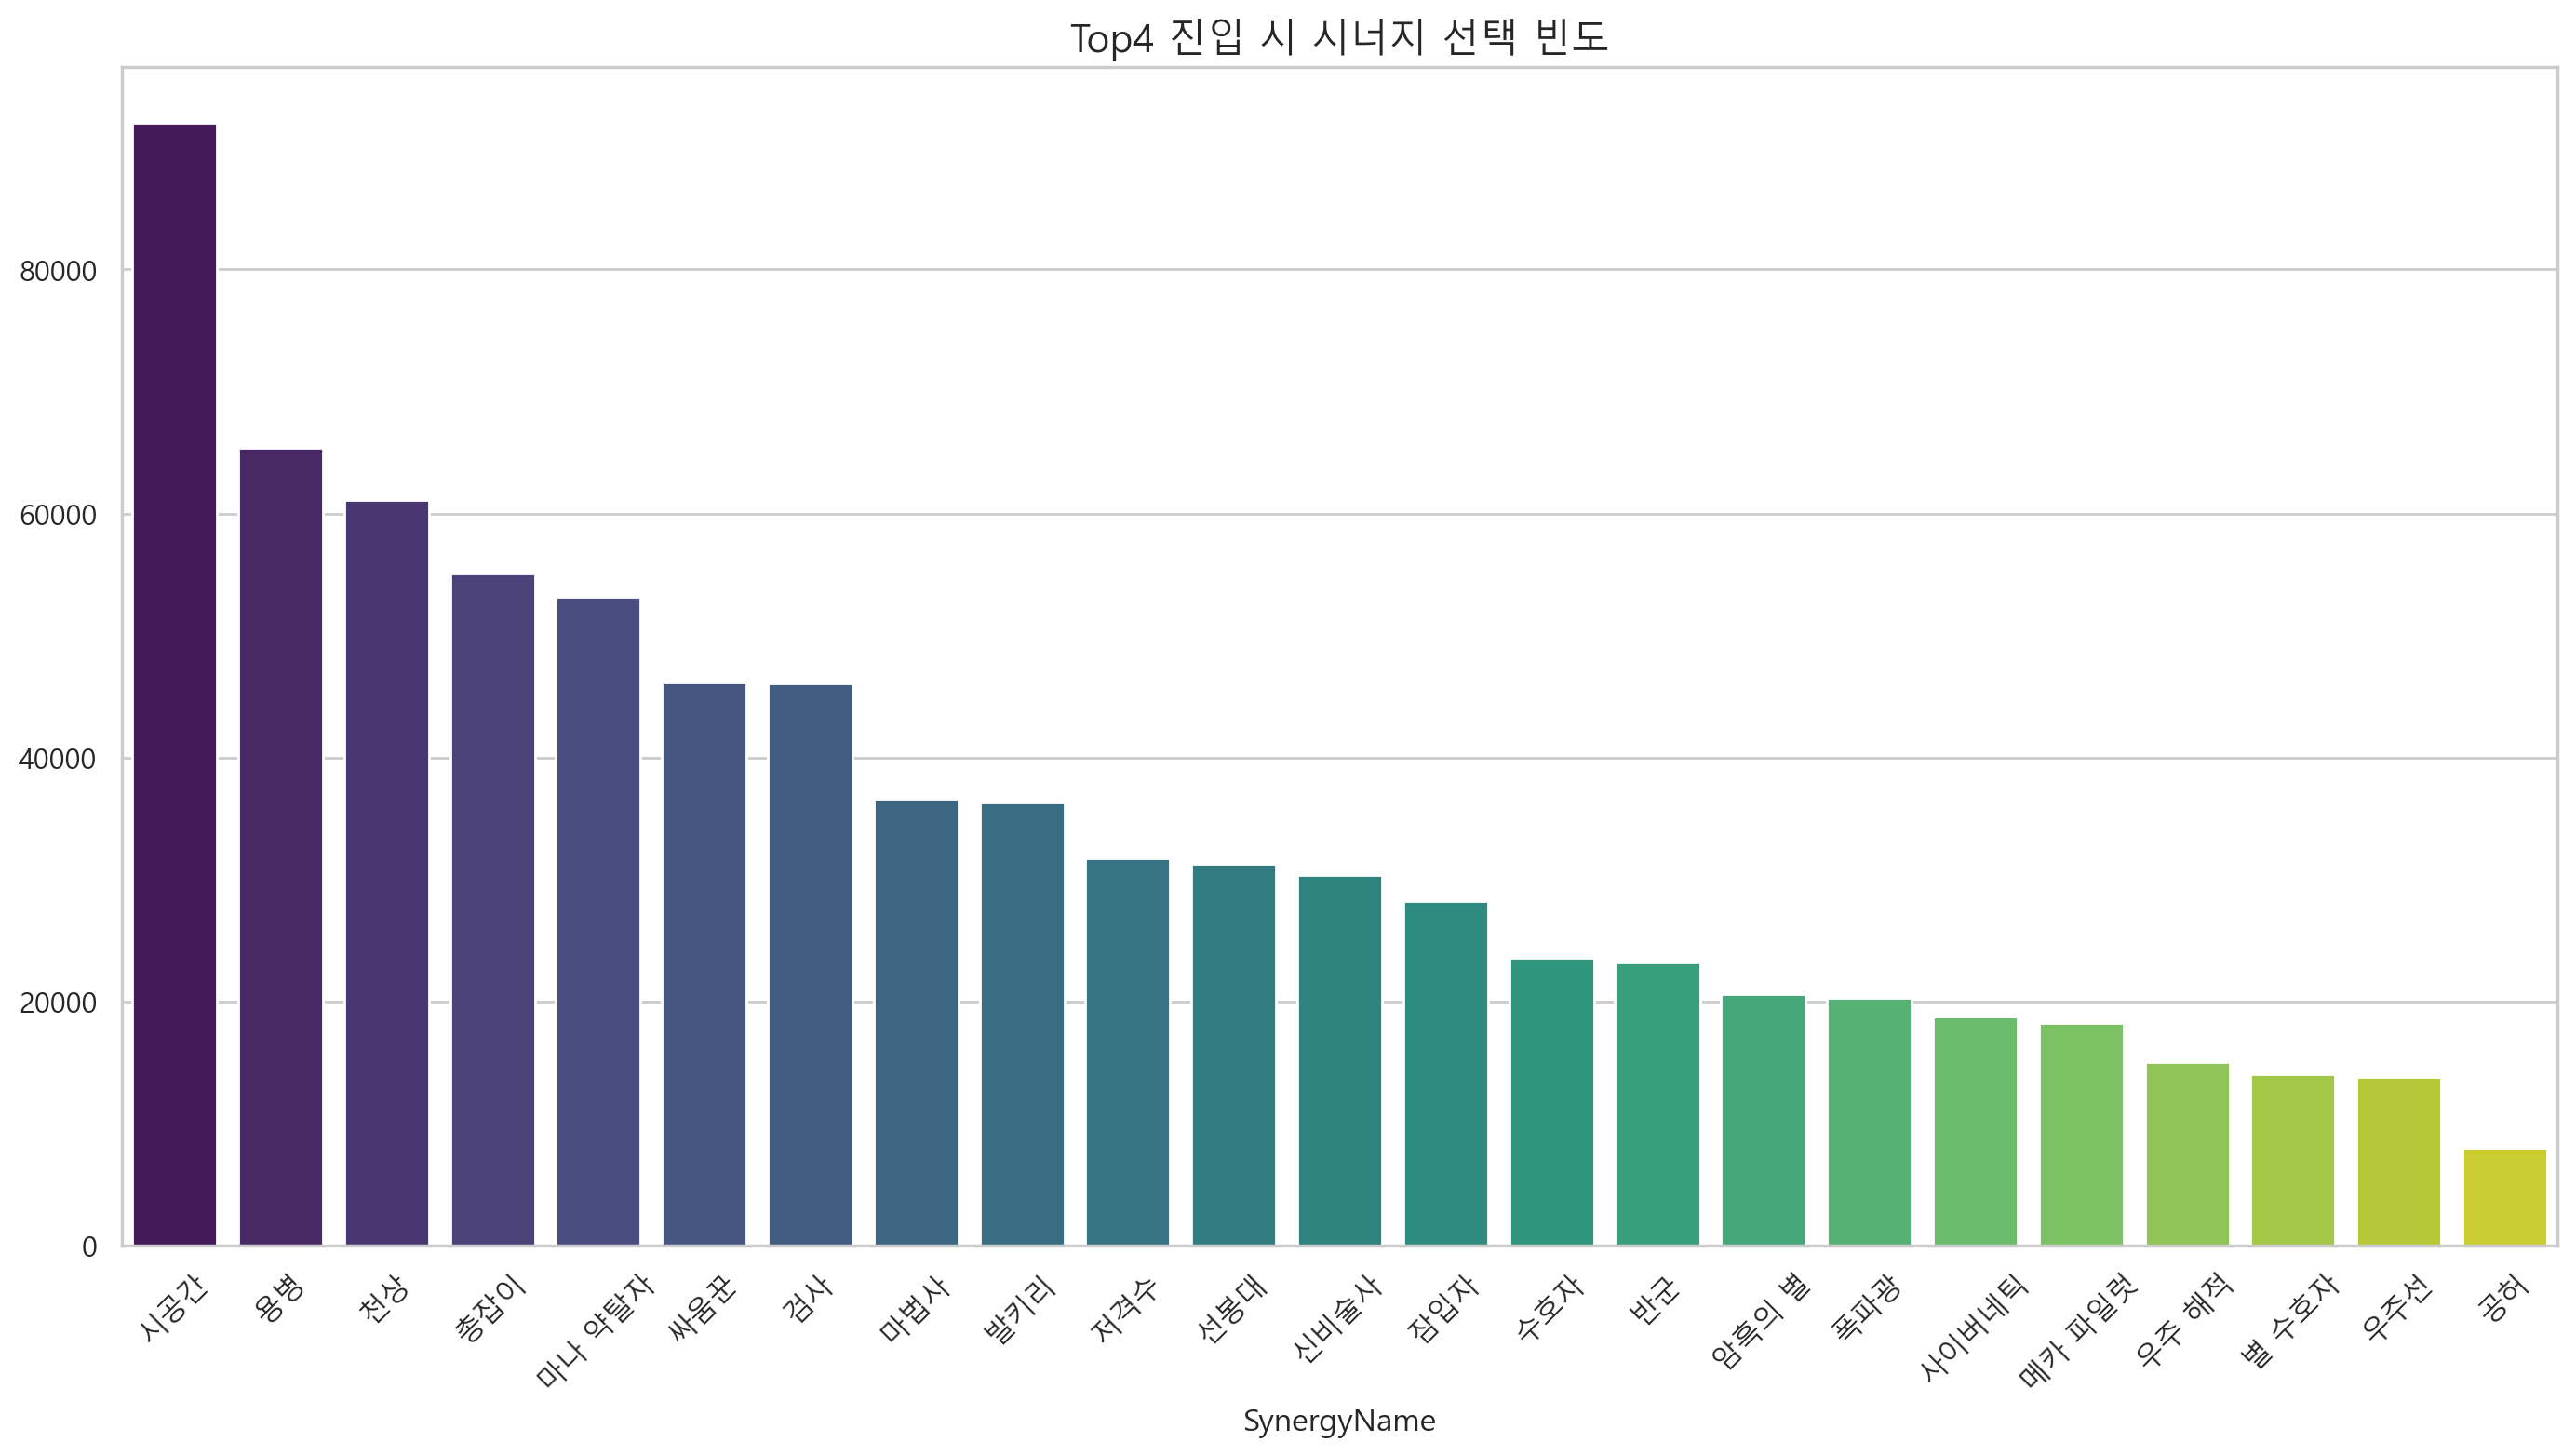

In [17]:
# Top4 진입 시너지 집계
win_counts = df_exploded[df_exploded['IsTop4'] == 1]['SynergyName'].value_counts().sort_values(ascending=False)

# Top4 시너지 선택 빈도 시각화
plt.figure(figsize=(14, 8))
sns.barplot(x=win_counts.index, y=win_counts.values, hue=win_counts.index, palette='viridis', legend=False)

# 차트 출력
plt.title('Top4 진입 시 시너지 선택 빈도', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 보상 기준
- 인기도×Top4 성과 기준 4개 구간 분류
- 저인기 고성능군은 선택 유도 보상, 고인기 저성능군은 자연 감소 방향

[사분면 해석]
- 저인기 고성능: 반군·신비술사·폭파광·우주선·공허, 선택 유도 보상 후보
- 고인기 저성능: 검사·싸움꾼·마법사·저격수·선봉대, 자연 감소 유도 후보

[보상 체계 방향]
- 저인기 고성능: 희귀 프리즘 카드, 선택 유도 보상
- 고인기 고성능: 기본 브론즈 카드, 추가 보상 억제
- 저인기 저성능: 골드/실버 카드, 진입 장벽 완화
- 고인기 저성능: 골드 보상, 자연 감소 유도 유지

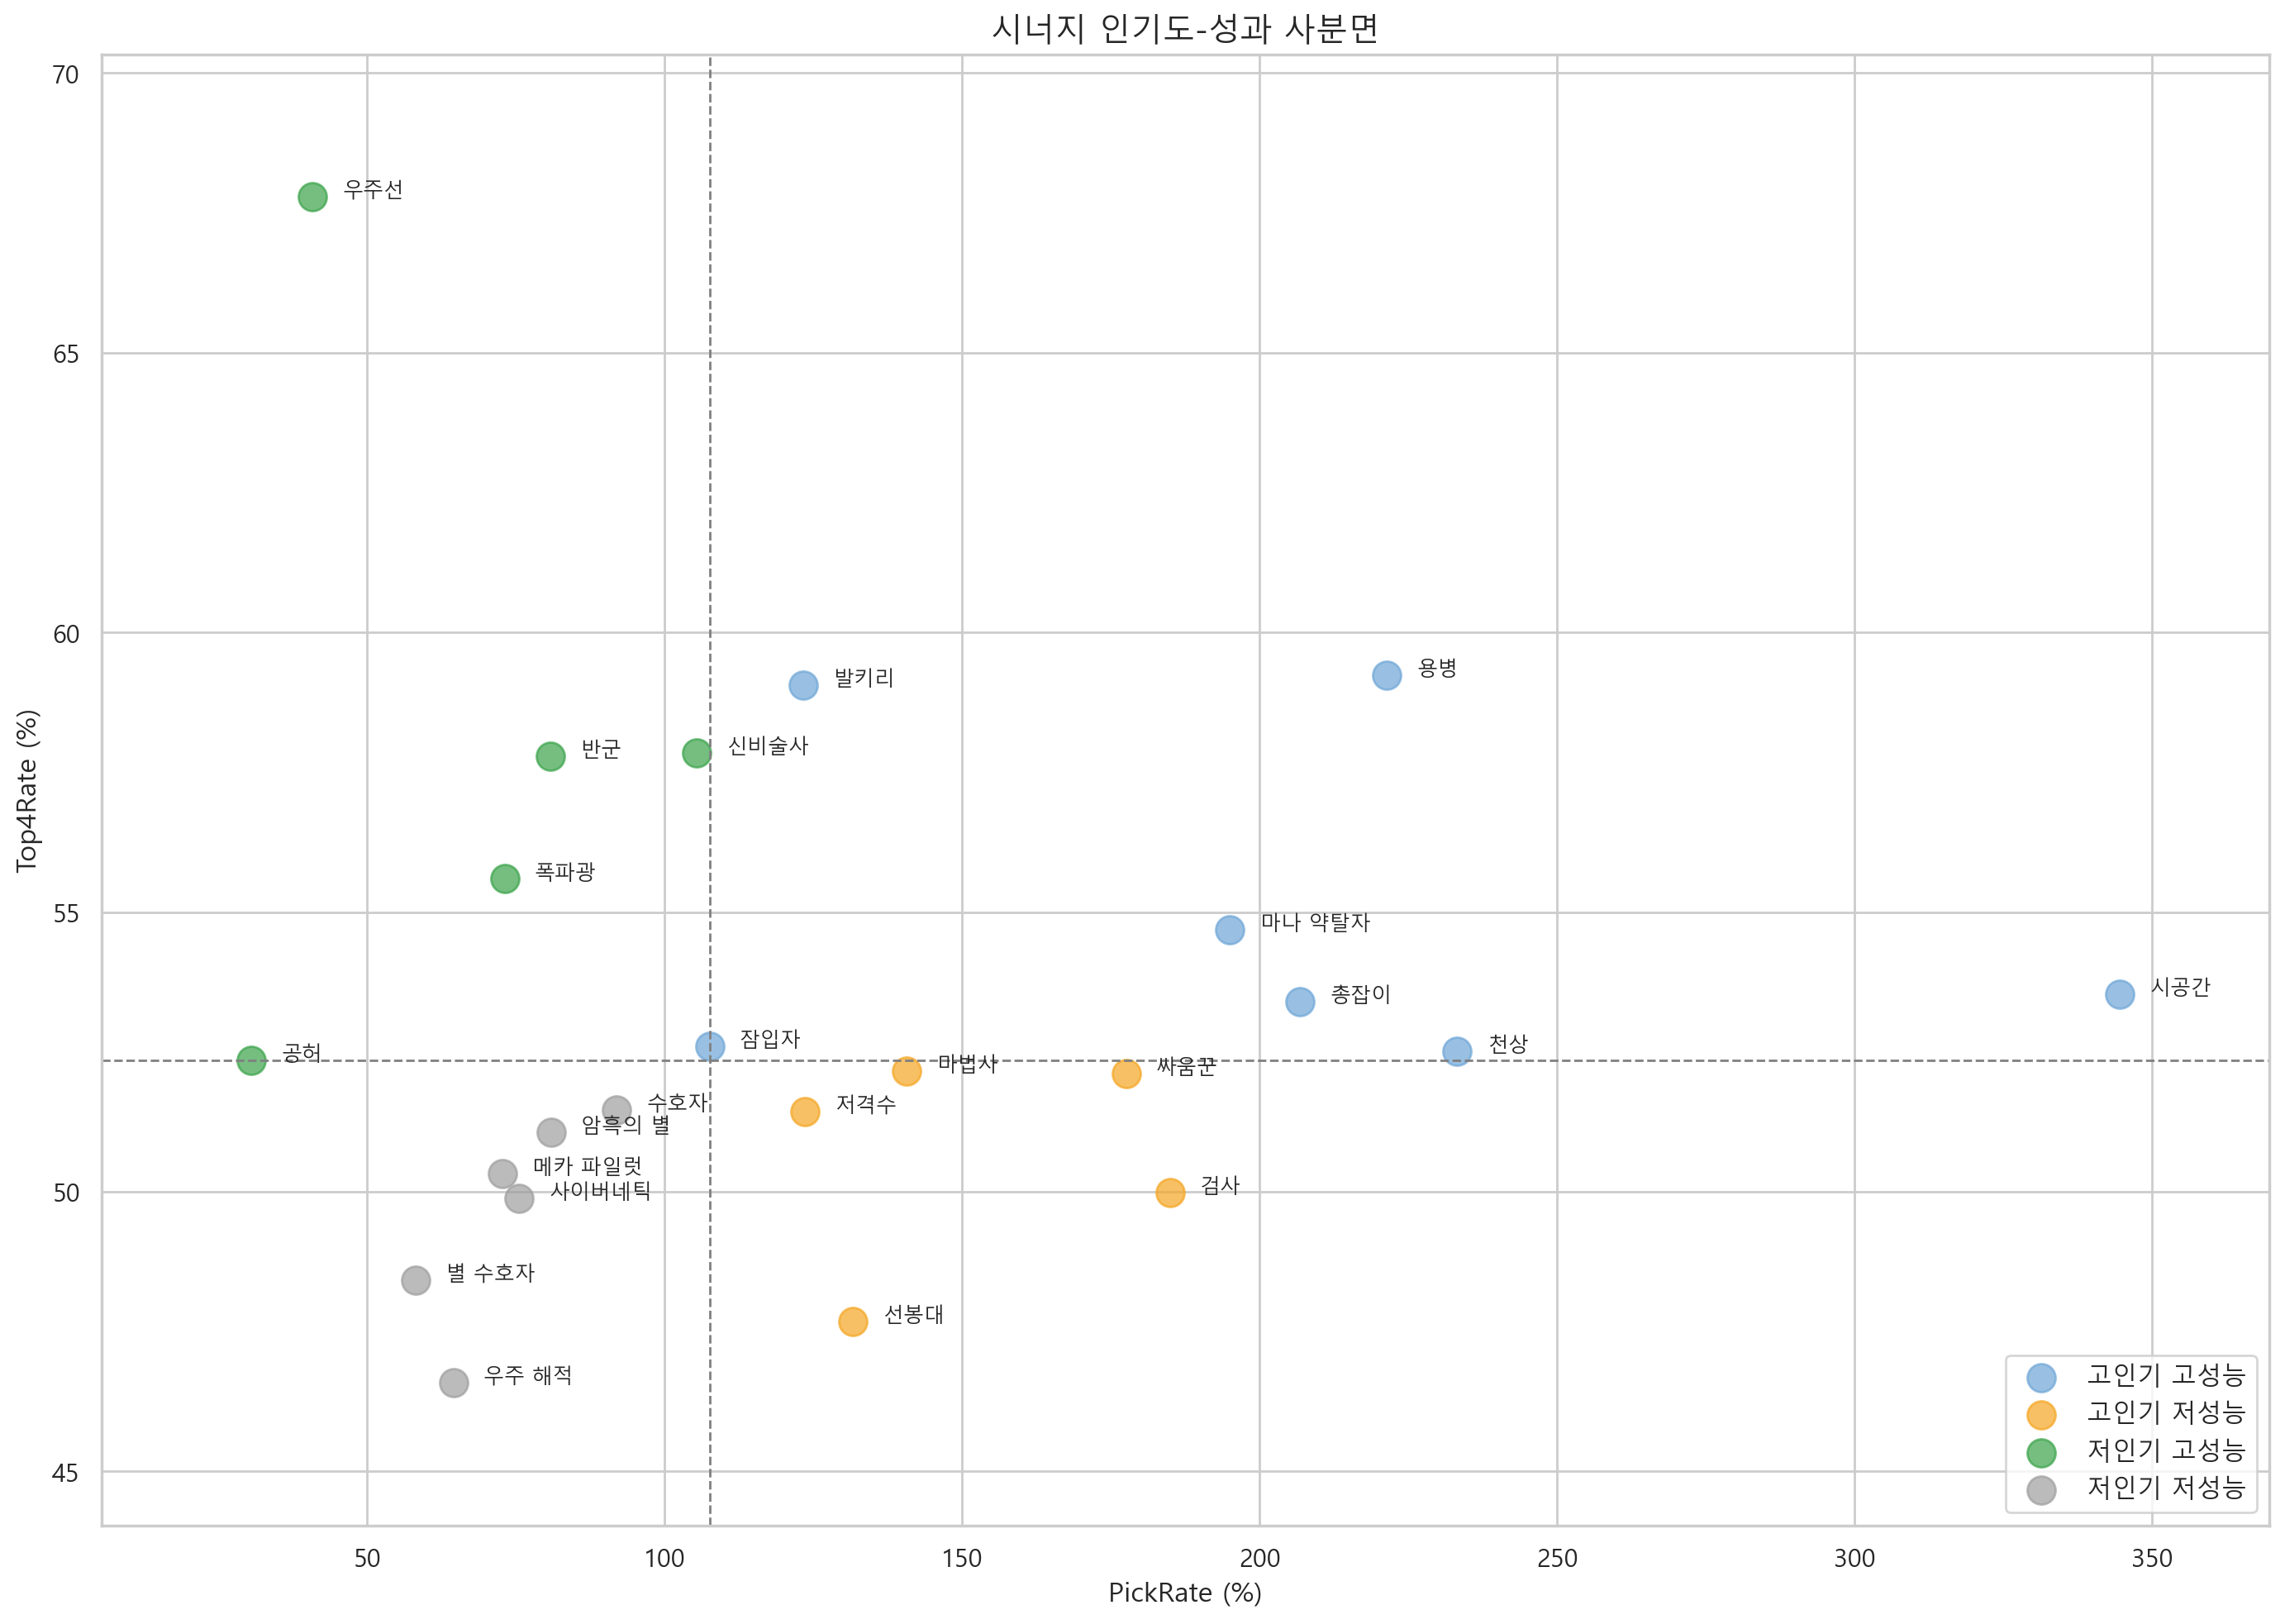

,PickRate,Top4Rate,segment
SynergyName,,,
시공간,344.554714,53.527642,고인기 고성능
천상,233.223064,52.509735,고인기 고성능
용병,221.388187,59.232594,고인기 고성능
총잡이,206.754481,53.391515,고인기 고성능
마나 약탈자,195.027868,54.677413,고인기 고성능
발키리,123.244717,59.061036,고인기 고성능
잠입자,107.548418,52.603322,고인기 고성능
검사,184.913188,49.991868,고인기 저성능
싸움꾼,177.533181,52.108413,고인기 저성능


In [18]:
# 시너지별 픽률·Top4율 집계
perf_df = df_exploded.groupby('SynergyName').agg(
    PickRate=('gameId', 'count'),
    Top4Rate=('IsTop4', 'mean')
)

# 비율 단위 변환
perf_df['PickRate'] = (perf_df['PickRate'] / total_games) * 100
perf_df['Top4Rate'] *= 100

# 사분면 기준값
pr_med = perf_df['PickRate'].median()
t4_med = perf_df['Top4Rate'].median()

# 인기도 x 성능 구간
# 저인기 고성능: 보상 유도 후보
# 고인기 저성능: 선택 완화 후보
def seg_label(row):
    if row['PickRate'] >= pr_med and row['Top4Rate'] >= t4_med:
        return '고인기 고성능'
    elif row['PickRate'] < pr_med and row['Top4Rate'] >= t4_med:
        return '저인기 고성능'
    elif row['PickRate'] >= pr_med and row['Top4Rate'] < t4_med:
        return '고인기 저성능'
    else:
        return '저인기 저성능'

perf_df['segment'] = perf_df.apply(seg_label, axis=1)

# 사분면 색상 설정
palette = {
    '저인기 고성능': '#3BA34A',
    '고인기 고성능': '#6EA6D7',
    '고인기 저성능': '#F5A623',
    '저인기 저성능': '#9E9E9E',
}

# 축 여백 계산
x_min = perf_df['PickRate'].min()
x_max = perf_df['PickRate'].max()
y_min = perf_df['Top4Rate'].min()
y_max = perf_df['Top4Rate'].max()
x_pad = (x_max - x_min) * 0.08
y_pad = (y_max - y_min) * 0.12

# 사분면 산점도 시각화
plt.figure(figsize=(14, 10))
for seg, grp in perf_df.groupby('segment'):
    plt.scatter(grp['PickRate'], grp['Top4Rate'], s=150, alpha=0.7,
                label=seg, color=palette[seg])
    
# 중앙 기준선 표시
plt.axvline(pr_med, color='grey', ls='--', lw=1)
plt.axhline(t4_med, color='grey', ls='--', lw=1)

# 시너지명 라벨 표시
for i in range(len(perf_df)):
    plt.text(perf_df['PickRate'].iloc[i] + x_pad * 0.2,
             perf_df['Top4Rate'].iloc[i],
             perf_df.index[i], fontsize=9)

plt.xlim(x_min - x_pad, x_max + x_pad)
plt.ylim(y_min - y_pad, y_max + y_pad)

plt.title('시너지 인기도-성과 사분면', fontsize=14)
plt.xlabel('PickRate (%)')
plt.ylabel('Top4Rate (%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 사분면 분류 결과 테이블
seg_result = perf_df[['PickRate', 'Top4Rate', 'segment']].sort_values(['segment', 'PickRate'], ascending=[True, False])
seg_result

### 보상 가중치 시뮬레이션
- 기존 선택 확률 기반으로 메타 집중 완화 방향의 경험적 가중치를 적용
- 저인기 고성능 시너지 선택 유도, 고인기 저성능 시너지 과점 완화 목적
- 운영 정책 가정 기반 시뮬레이션으로 추후 가중치 조정 가능

#### 결과 해석
- HHI 576.8 → 563.5 (-2.31%)
  → 시너지 선택 집중도 감소
- 저인기 고성능
  11.15% → 12.78% (+1.63%p)
  → 비주류 고성능 시너지 선택 증가
- 고인기 저성능
  25.58% → 22.95% (-2.63%p)
  → 메타 과점 완화 방향 확인

In [19]:
# 시너지별 픽률·Top4율(승률) 집계
syn_df = df_exploded.groupby('SynergyName').agg(
    pick_count=('gameId', 'count'),
    top4_rate=('IsTop4', 'mean')
)

# 사분면 기준값
pick_med = syn_df['pick_count'].median()
top4_med = syn_df['top4_rate'].median()

# 인기도 x 성능 구간 분류
def seg_code(row):
    if row['pick_count'] >= pick_med and row['top4_rate'] >= top4_med:
        return 'high_pop_high_perf'
    elif row['pick_count'] < pick_med and row['top4_rate'] >= top4_med:
        return 'low_pop_high_perf'
    elif row['pick_count'] >= pick_med and row['top4_rate'] < top4_med:
        return 'high_pop_low_perf'
    else:
        return 'low_pop_low_perf'

syn_df['seg'] = syn_df.apply(seg_code, axis=1)

# 현재 픽률 계산
total_picks = syn_df['pick_count'].sum()
syn_df['pick_rate_now'] = syn_df['pick_count'] / total_picks

# 보상 가중치 설정
# 저인기 고성능 선택 유도, 고인기 저성능 과점 완화
weight = {
    'low_pop_high_perf': 1.15,
    'high_pop_high_perf': 1.00,
    'high_pop_low_perf': 0.90,
    'low_pop_low_perf': 1.08,
}

# 보상 후 가중치 기반 픽률 재분배
# 보상 조정에 따른 선택 유도 보상 가정
syn_df['pick_adj'] = syn_df.apply(
    lambda x: x['pick_rate_now'] * weight[x['seg']],
    axis=1
)

# 재분배 후 픽률 정규화
syn_df['pick_rate_sim'] = syn_df['pick_adj'] / syn_df['pick_adj'].sum()

# HHI
# 0~10,000 기준, 낮을수록 선택 분산
def calc_hhi(pick_rate):
    return (pick_rate ** 2).sum() * 10000

# 시뮬레이션 전후 HHI 변화
hhi_before = calc_hhi(syn_df['pick_rate_now'])
hhi_after = calc_hhi(syn_df['pick_rate_sim'])
hhi_delta_pct = (hhi_before - hhi_after) / hhi_before * 100

# 구간명 한글 변환
seg_name = {
    'low_pop_high_perf': '저인기 고성능',
    'high_pop_high_perf': '고인기 고성능',
    'high_pop_low_perf': '고인기 저성능',
    'low_pop_low_perf': '저인기 저성능',
}

# 구간별 픽률 변화 요약
seg_sim = (
    syn_df.groupby('seg')[['pick_rate_now', 'pick_rate_sim']]
    .sum()
    .mul(100)
    .assign(delta_pctp=lambda x: x['pick_rate_sim'] - x['pick_rate_now'])
    .round(2)
    .rename(index=seg_name)
    .rename(columns={
        'pick_rate_now': 'before_pct',
        'pick_rate_sim': 'after_pct',
        'delta_pctp': 'delta_pctp',
    })
)

# HHI 변화 요약
hhi_check = pd.Series({
    'hhi_before': round(hhi_before, 1),
    'hhi_after': round(hhi_after, 1),
    'hhi_delta_pct': round(hhi_delta_pct, 2),
})

display(hhi_check)

# 구간별 재분배 결과
seg_sim

hhi_before       576.80
hhi_after        563.50
hhi_delta_pct      2.31
dtype: float64

,before_pct,after_pct,delta_pctp
seg,,,
고인기 고성능,48.30,48.15,-0.15
고인기 저성능,25.58,22.95,-2.63
저인기 고성능,11.15,12.78,1.63
저인기 저성능,14.97,16.12,1.15
